In [1]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
        print(dirname)


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/muhammadraiyansani
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/test
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/train
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/train/0_Recyclable
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/train/1_Electronic
/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/train/2_Organic


In [2]:
import os
import pandas as pd
from pathlib import Path

# 1. Definisikan base path dataset di Kaggle
base_path = Path("/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026")
train_dir = base_path / "train"
test_dir = base_path / "test"

# Validasi direktori
if not train_dir.exists():
    raise FileNotFoundError(f"Direktori Train tidak ditemukan pada path: {train_dir}")

# 2. Load Data Train
train_records = []
for class_folder in sorted(os.listdir(train_dir)):
    class_path = train_dir / class_folder
    if class_path.is_dir():
        for filename in os.listdir(class_path):
            file_path = class_path / filename
            # Filter hanya file gambar
            if file_path.is_file() and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                train_records.append({
                    "file_path": str(file_path),
                    "filename": filename,
                    "label": class_folder
                })

df_train = pd.DataFrame(train_records)

# 3. Load Data Test
test_records = []
if test_dir.exists():
    for filename in sorted(os.listdir(test_dir)):
        file_path = test_dir / filename
        # Filter hanya file gambar
        if file_path.is_file() and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_records.append({
                "file_path": str(file_path),
                "filename": filename
            })

df_test = pd.DataFrame(test_records)

# 4. Menampilkan Informasi Awal
print("=== RINGKASAN DATASET ===")
print(f"Total Data Train : {len(df_train)}")
print(f"Total Data Test  : {len(df_test)}")

print("\n--- Distribusi Kelas Data Train ---")
print(df_train['label'].value_counts())

print("\n--- Preview Data Train ---")
display(df_train.head())

print("\n--- Preview Data Test ---")
display(df_test.head())


=== RINGKASAN DATASET ===
Total Data Train : 26527
Total Data Test  : 1458

--- Distribusi Kelas Data Train ---
label
2_Organic       12567
0_Recyclable     9999
1_Electronic     3961
Name: count, dtype: int64

--- Preview Data Train ---


,file_path,filename,label
0,/kaggle/input/datasets/muhammadraiyansani/bdc-...,R_6214.jpg,0_Recyclable
1,/kaggle/input/datasets/muhammadraiyansani/bdc-...,R_8141.jpg,0_Recyclable
2,/kaggle/input/datasets/muhammadraiyansani/bdc-...,R_2463.jpg,0_Recyclable
3,/kaggle/input/datasets/muhammadraiyansani/bdc-...,R_9892.jpg,0_Recyclable
4,/kaggle/input/datasets/muhammadraiyansani/bdc-...,R_5469.jpg,0_Recyclable



--- Preview Data Test ---


,file_path,filename
0,/kaggle/input/datasets/muhammadraiyansani/bdc-...,1.jpg
1,/kaggle/input/datasets/muhammadraiyansani/bdc-...,10.jpg
2,/kaggle/input/datasets/muhammadraiyansani/bdc-...,100.jpg
3,/kaggle/input/datasets/muhammadraiyansani/bdc-...,1000.jpg
4,/kaggle/input/datasets/muhammadraiyansani/bdc-...,1001.jpg


In [3]:
# 1. Menampilkan informasi tipe data dan missing values (non-null)
print("=== INFO DATA TRAIN ===")
df_train.info()

print("\n=== INFO DATA TEST ===")
df_test.info()

# 2. Menampilkan deskripsi statistik (termasuk kolom kategorikal/teks)
print("\n=== DESKRIPSI STATISTIK DATA TRAIN ===")
display(df_train.describe(include='all'))

# 3. Menampilkan distribusi label dalam jumlah asli dan persentase
print("\n=== DISTRIBUSI KELAS (JUMLAH KASUS) ===")
display(df_train['label'].value_counts())

print("\n=== DISTRIBUSI KELAS (PERSENTASE) ===")
display(df_train['label'].value_counts(normalize=True) * 100)


=== INFO DATA TRAIN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26527 entries, 0 to 26526
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_path  26527 non-null  object
 1   filename   26527 non-null  object
 2   label      26527 non-null  object
dtypes: object(3)
memory usage: 621.9+ KB

=== INFO DATA TEST ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_path  1458 non-null   object
 1   filename   1458 non-null   object
dtypes: object(2)
memory usage: 22.9+ KB

=== DESKRIPSI STATISTIK DATA TRAIN ===


,file_path,filename,label
count,26527,26527,26527
unique,26527,26527,3
top,/kaggle/input/datasets/muhammadraiyansani/bdc-...,O_9731.jpg,2_Organic
freq,1,1,12567



=== DISTRIBUSI KELAS (JUMLAH KASUS) ===


label
2_Organic       12567
0_Recyclable     9999
1_Electronic     3961
Name: count, dtype: int64


=== DISTRIBUSI KELAS (PERSENTASE) ===


label
2_Organic       47.374373
0_Recyclable    37.693671
1_Electronic    14.931956
Name: proportion, dtype: float64

Mengekstrak resolusi gambar...


  0%|          | 0/26527 [00:00<?, ?it/s]

📊 STATISTIK RESOLUSI GAMBAR PER KELAS

▶ Kelas: 0_Recyclable
  - Rata-rata Lebar x Tinggi : 242.3 px x 211.7 px
  - Median Lebar x Tinggi    : 225.0 px x 224.0 px
  - Rentang Lebar            : Min 56 px s/d Max 569 px
  - Rentang Tinggi           : Min 88 px s/d Max 346 px
  - Rata-rata Total Piksel   : 0.050 MP (Megapixels)
  - Dimensi Terpendek (Min)  : 56 px

▶ Kelas: 1_Electronic
  - Rata-rata Lebar x Tinggi : 604.7 px x 515.0 px
  - Median Lebar x Tinggi    : 150.0 px x 150.0 px
  - Rentang Lebar            : Min 150 px s/d Max 8000 px
  - Rentang Tinggi           : Min 113 px s/d Max 6000 px
  - Rata-rata Total Piksel   : 1.101 MP (Megapixels)
  - Dimensi Terpendek (Min)  : 113 px

▶ Kelas: 2_Organic
  - Rata-rata Lebar x Tinggi : 260.3 px x 197.4 px
  - Median Lebar x Tinggi    : 263.0 px x 190.0 px
  - Rentang Lebar            : Min 51 px s/d Max 600 px
  - Rentang Tinggi           : Min 69 px s/d Max 383 px
  - Rata-rata Total Piksel   : 0.050 MP (Megapixels)
  - Dimensi Terp

resolution_category,1. Sangat Kecil (< 100px),2. Kecil (100px - 256px),3. Sedang (257px - 512px),4. Besar (513px - 1024px),5. Sangat Besar (> 1024px)
label,,,,,
0_Recyclable,0.77 %,99.23 %,0.0 %,0.0 %,0.0 %
1_Electronic,0.0 %,68.19 %,6.61 %,16.64 %,8.56 %
2_Organic,0.25 %,99.75 %,0.0 %,0.0 %,0.0 %


/tmp/ipykernel_16/3267507359.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='label', y='total_pixels', palette='Set2', ax=axes[1])


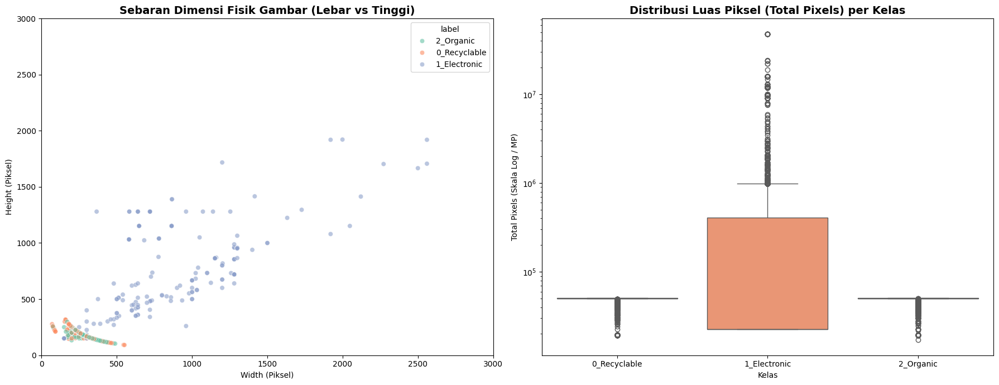

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

# --- 1. Pastikan Dimensi Gambar Sudah Terekstrak ---
if 'width' not in df_train.columns:
    widths, heights = [], []
    print("Mengekstrak resolusi gambar...")
    for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
        try:
            with Image.open(row['file_path']) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception:
            widths.append(np.nan)
            heights.append(np.nan)
    df_train['width'] = widths
    df_train['height'] = heights

# Tambahkan fitur total piksel (Megapiksel) untuk mengukur resolusi area
df_train['total_pixels'] = df_train['width'] * df_train['height']
df_train['min_dim'] = df_train[['width', 'height']].min(axis=1) # Dimensi terpendek

# --- 2. Statistik Deskriptif Resolusi Lengkap per Kelas ---
print("="*60)
print("📊 STATISTIK RESOLUSI GAMBAR PER KELAS")
print("="*60)

for label in sorted(df_train['label'].unique()):
    subset = df_train[df_train['label'] == label]
    print(f"\n▶ Kelas: {label}")
    print(f"  - Rata-rata Lebar x Tinggi : {subset['width'].mean():.1f} px x {subset['height'].mean():.1f} px")
    print(f"  - Median Lebar x Tinggi    : {subset['width'].median():.1f} px x {subset['height'].median():.1f} px")
    print(f"  - Rentang Lebar            : Min {subset['width'].min():.0f} px s/d Max {subset['width'].max():.0f} px")
    print(f"  - Rentang Tinggi           : Min {subset['height'].min():.0f} px s/d Max {subset['height'].max():.0f} px")
    print(f"  - Rata-rata Total Piksel   : {subset['total_pixels'].mean()/1e6:.3f} MP (Megapixels)")
    print(f"  - Dimensi Terpendek (Min)  : {subset['min_dim'].min():.0f} px")

# --- 3. Pengelompokan Rentang Resolusi (Binning) per Kelas ---
def categorize_resolution(min_dim):
    if min_dim < 100:
        return "1. Sangat Kecil (< 100px)"
    elif min_dim <= 256:
        return "2. Kecil (100px - 256px)"
    elif min_dim <= 512:
        return "3. Sedang (257px - 512px)"
    elif min_dim <= 1024:
        return "4. Besar (513px - 1024px)"
    else:
        return "5. Sangat Besar (> 1024px)"

df_train['resolution_category'] = df_train['min_dim'].apply(categorize_resolution)

print("\n" + "="*60)
print("🏷️ DISTRIBUSI KELOMPOK RESOLUSI PER KELAS")
print("="*60)
# Buat tabel silang (crosstab) persentase kelompok resolusi per kelas
resolution_crosstab = pd.crosstab(df_train['label'], df_train['resolution_category'], normalize='index') * 100
display(resolution_crosstab.round(2).astype(str) + " %")

# --- 4. Visualisasi Sebaran Spasial Lebar vs Tinggi ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter Plot: Sebaran Width vs Height
sns.scatterplot(
    data=df_train.sample(n=min(5000, len(df_train)), random_state=42), # Sampling 5000 agar grafik cepat dirender
    x='width', y='height', hue='label', alpha=0.6, palette='Set2', ax=axes[0]
)
axes[0].set_title("Sebaran Dimensi Fisik Gambar (Lebar vs Tinggi)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Width (Piksel)")
axes[0].set_ylabel("Height (Piksel)")
# Batasi sumbu agar outliers ekstrim tidak merusak visualisasi utama
axes[0].set_xlim(0, 3000)
axes[0].set_ylim(0, 3000)

# Boxplot: Total Piksel per Kelas (Skala Logaritmik karena perbedaan ekstrim)
sns.boxplot(data=df_train, x='label', y='total_pixels', palette='Set2', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title("Distribusi Luas Piksel (Total Pixels) per Kelas", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Total Pixels (Skala Log / MP)")
axes[1].set_xlabel("Kelas")

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np

# --- 1. Hitung Aspek Rasio (Width / Height) jika belum ada ---
if 'aspect_ratio' not in df_train.columns:
    df_train['aspect_ratio'] = df_train['width'] / df_train['height']

print("="*60)
print("📐 ANALISIS STATISTIK ASPEK RASIO DETAIL PER KELAS")
print("="*60)

for label in sorted(df_train['label'].unique()):
    subset = df_train[df_train['label'] == label]
    ar = subset['aspect_ratio'].dropna()
    
    print(f"\n▶ Kelas: {label}")
    print(f"  - Jumlah Gambar        : {len(subset)}")
    print(f"  - Rata-rata Aspek Rasio : {ar.mean():.4f}")
    print(f"  - Median Aspek Rasio    : {ar.median():.4f}")
    print(f"  - Standar Deviasi (Std) : {ar.std():.4f}")
    print(f"  - Rentang Aspek Rasio   : Min {ar.min():.4f} s/d Max {ar.max():.4f}")
    
    # Menghitung Persentil untuk mendeteksi pencilan ekstrim
    p1, p5, p95, p99 = np.percentile(ar, [1, 5, 95, 99])
    print(f"  - Persentil 1% (Kiri)  : {p1:.4f} (Sangat Portrait)")
    print(f"  - Persentil 5%         : {p5:.4f}")
    print(f"  - Persentil 95%        : {p95:.4f}")
    print(f"  - Persentil 99% (Kanan) : {p99:.4f} (Sangat Landscape)")

# --- 2. Distribusi Geometris Gambar per Kelas ---
def categorize_aspect_ratio(ar):
    if ar < 0.5:
        return "1. Portrait Ekstrem (< 0.5)"
    elif ar < 0.9:
        return "2. Portrait Normal (0.5 - 0.89)"
    elif ar <= 1.1:
        return "3. Hampir Kotak / Square (0.9 - 1.1)"
    elif ar <= 2.0:
        return "4. Landscape Normal (1.11 - 2.0)"
    else:
        return "5. Landscape Ekstrem (> 2.0)"

df_train['aspect_ratio_category'] = df_train['aspect_ratio'].apply(categorize_aspect_ratio)

print("\n" + "="*60)
print("📊 PERSENTASE BENTUK GEOMETRIS GAMBAR PER KELAS")
print("="*60)
# Tabel silang jumlah kasus
crosstab_count = pd.crosstab(df_train['label'], df_train['aspect_ratio_category'])
print("\n--- Jumlah Gambar per Kategori Bentuk ---")
display(crosstab_count)

# Tabel silang persentase
crosstab_pct = pd.crosstab(df_train['label'], df_train['aspect_ratio_category'], normalize='index') * 100
print("\n--- Persentase (%) Gambar per Kategori Bentuk ---")
display(crosstab_pct.round(2).astype(str) + " %")

# --- 3. Audit Batas Ekstrem (< 0.33 atau > 3.0) ---
print("\n" + "="*60)
print("🚨 DETEKSI GAMBAR DENGAN ASPEK RASIO EKSTREM (< 0.33 atau > 3.0)")
print("="*60)

for label in sorted(df_train['label'].unique()):
    subset = df_train[df_train['label'] == label]
    ar = subset['aspect_ratio'].dropna()
    
    # Hitung di bawah 0.33 (sangat tinggi)
    too_tall = (ar < 0.33).sum()
    # Hitung di atas 3.0 (sangat lebar)
    too_wide = (ar > 3.0).sum()
    total_outliers = too_tall + too_wide
    
    print(f"▶ Kelas: {label}")
    print(f"  - Terlalu Tinggi (< 0.33)  : {too_tall} gambar ({too_tall/len(subset)*100:.2f}%)")
    print(f"  - Terlalu Lebar (> 3.0)   : {too_wide} gambar ({too_wide/len(subset)*100:.2f}%)")
    print(f"  - Total Outliers Dibuang   : {total_outliers} gambar ({total_outliers/len(subset)*100:.2f}%)")


📐 ANALISIS STATISTIK ASPEK RASIO DETAIL PER KELAS

▶ Kelas: 0_Recyclable
  - Jumlah Gambar        : 9999
  - Rata-rata Aspek Rasio : 1.2113
  - Median Aspek Rasio    : 1.0000
  - Standar Deviasi (Std) : 0.4574
  - Rentang Aspek Rasio   : Min 0.1618 s/d Max 6.4659
  - Persentil 1% (Kiri)  : 0.5209 (Sangat Portrait)
  - Persentil 5%         : 0.6691
  - Persentil 95%        : 1.9198
  - Persentil 99% (Kanan) : 2.8571 (Sangat Landscape)

▶ Kelas: 1_Electronic
  - Jumlah Gambar        : 3961
  - Rata-rata Aspek Rasio : 1.1048
  - Median Aspek Rasio    : 1.0000
  - Standar Deviasi (Std) : 0.2984
  - Rentang Aspek Rasio   : Min 0.2859 s/d Max 4.0000
  - Persentil 1% (Kiri)  : 0.5000 (Sangat Portrait)
  - Persentil 5%         : 0.7500
  - Persentil 95%        : 1.7778
  - Persentil 99% (Kanan) : 2.0000 (Sangat Landscape)

▶ Kelas: 2_Organic
  - Jumlah Gambar        : 12567
  - Rata-rata Aspek Rasio : 1.3861
  - Median Aspek Rasio    : 1.3822
  - Standar Deviasi (Std) : 0.4611
  - Rentang Aspe

aspect_ratio_category,1. Portrait Ekstrem (< 0.5),2. Portrait Normal (0.5 - 0.89),3. Hampir Kotak / Square (0.9 - 1.1),4. Landscape Normal (1.11 - 2.0),5. Landscape Ekstrem (> 2.0)
label,,,,,
0_Recyclable,72,1875,3486,4208,358
1_Electronic,20,262,2745,909,25
2_Organic,23,1377,2368,8175,624



--- Persentase (%) Gambar per Kategori Bentuk ---


aspect_ratio_category,1. Portrait Ekstrem (< 0.5),2. Portrait Normal (0.5 - 0.89),3. Hampir Kotak / Square (0.9 - 1.1),4. Landscape Normal (1.11 - 2.0),5. Landscape Ekstrem (> 2.0)
label,,,,,
0_Recyclable,0.72 %,18.75 %,34.86 %,42.08 %,3.58 %
1_Electronic,0.5 %,6.61 %,69.3 %,22.95 %,0.63 %
2_Organic,0.18 %,10.96 %,18.84 %,65.05 %,4.97 %



🚨 DETEKSI GAMBAR DENGAN ASPEK RASIO EKSTREM (< 0.33 atau > 3.0)
▶ Kelas: 0_Recyclable
  - Terlalu Tinggi (< 0.33)  : 17 gambar (0.17%)
  - Terlalu Lebar (> 3.0)   : 79 gambar (0.79%)
  - Total Outliers Dibuang   : 96 gambar (0.96%)
▶ Kelas: 1_Electronic
  - Terlalu Tinggi (< 0.33)  : 1 gambar (0.03%)
  - Terlalu Lebar (> 3.0)   : 5 gambar (0.13%)
  - Total Outliers Dibuang   : 6 gambar (0.15%)
▶ Kelas: 2_Organic
  - Terlalu Tinggi (< 0.33)  : 9 gambar (0.07%)
  - Terlalu Lebar (> 3.0)   : 117 gambar (0.93%)
  - Total Outliers Dibuang   : 126 gambar (1.00%)


In [6]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Menggunakan 100% Dataset (Tanpa Sampling) ---
print("Memproses 100% dari total dataset...")
print(f"Jumlah gambar yang dianalisis: {len(df_train)} gambar")
print(df_train['label'].value_counts())

# --- 2. Fungsi Ekstraksi Fitur Komposisi Gambar ---
def extract_image_composition(image_path):
    try:
        # Load gambar menggunakan OpenCV
        img = cv2.imread(image_path)
        if img is None:
            return [np.nan] * 8
            
        # A. Hitung Kontras & Value (Grayscale)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        contrast = gray.std()
        
        # B. Hitung Kepadatan Tepi (Canny Edge Density)
        edges = cv2.Canny(gray, threshold1=100, threshold2=200)
        edge_density = (edges > 0).mean()
        
        # C. Konversi ke HSV untuk analisis warna
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)
        
        # D. Ekstrak statistik warna (Rata-rata dan Standar Deviasi)
        mean_h, std_h = h.mean(), h.std()
        mean_s, std_s = s.mean(), s.std()
        mean_v, std_v = v.mean(), v.std()
        
        return [mean_h, std_h, mean_s, std_s, mean_v, std_v, contrast, edge_density]
        
    except Exception:
        return [np.nan] * 8

# --- 3. Eksekusi Paralel menggunakan Multithreading ---
paths = df_train['file_path'].tolist()
features = []

print("\nMengekstrak fitur visual (Warna & Tekstur) menggunakan Multithreading...")
# Menggunakan max_workers=8 untuk pemrosesan paralel cepat
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(extract_image_composition, paths), total=len(paths)))

# Gabungkan hasil ekstraksi kembali ke DataFrame utama
columns = [
    'mean_hue', 'std_hue', 'mean_saturation', 'std_saturation', 
    'mean_brightness', 'std_brightness', 'contrast', 'edge_density'
]
df_features = pd.DataFrame(results, columns=columns, index=df_train.index)
df_train = pd.concat([df_train, df_features], axis=1).dropna(subset=['edge_density'])

# --- 4. Tampilkan Laporan Statistik Angka Presisi per Kelas ---
print("\n" + "="*70)
print("📊 RATA-RATA KOMPOSISI VISUAL PER KELAS (100% DATA)")
print("="*70)
summary_mean = df_train.groupby('label')[columns].mean()
display(summary_mean.round(4))

print("\n" + "="*70)
print("📉 STANDAR DEVIASI (VARIASI) KOMPOSISI VISUAL PER KELAS (100% DATA)")
print("="*70)
summary_std = df_train.groupby('label')[columns].std()
display(summary_std.round(4))


Memproses 100% dari total dataset...
Jumlah gambar yang dianalisis: 26527 gambar
label
2_Organic       12567
0_Recyclable     9999
1_Electronic     3961
Name: count, dtype: int64

Mengekstrak fitur visual (Warna & Tekstur) menggunakan Multithreading...


  0%|          | 0/26527 [00:00<?, ?it/s]


📊 RATA-RATA KOMPOSISI VISUAL PER KELAS (100% DATA)


,mean_hue,std_hue,mean_saturation,std_saturation,mean_brightness,std_brightness,contrast,edge_density
label,,,,,,,,
0_Recyclable,43.2594,39.7595,50.1033,48.9048,194.8658,50.8597,55.8906,0.0896
1_Electronic,48.3181,42.1902,49.2148,43.6458,146.6254,69.1861,68.8323,0.0772
2_Organic,36.9992,35.6101,103.2825,66.9927,175.3001,56.2252,59.4043,0.1284



📉 STANDAR DEVIASI (VARIASI) KOMPOSISI VISUAL PER KELAS (100% DATA)


,mean_hue,std_hue,mean_saturation,std_saturation,mean_brightness,std_brightness,contrast,edge_density
label,,,,,,,,
0_Recyclable,31.0469,18.6892,45.7289,31.8076,44.0466,24.5137,23.5041,0.0748
1_Electronic,27.2112,15.3985,39.8429,26.7644,43.1692,21.0396,21.0374,0.0608
2_Organic,21.6055,17.5937,50.2718,22.1952,43.0488,20.4737,18.1288,0.0832


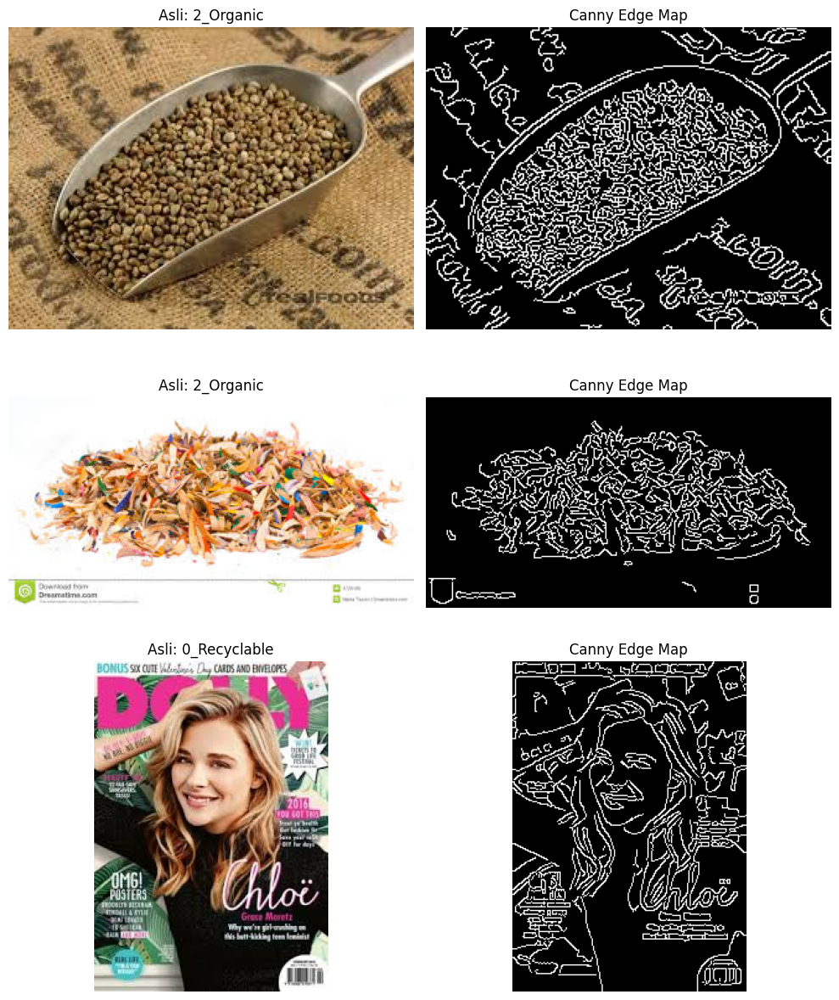

In [7]:
import cv2
import matplotlib.pyplot as plt

def visualize_canny_samples(df, num_samples=3):
    # Mengambil beberapa sampel gambar secara acak
    samples = df.sample(num_samples, random_state=42)
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))
    
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row['file_path']
        label = row['label']
        
        # Baca gambar asli (BGR ke RGB)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Gagal membaca gambar: {img_path}")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Proses Canny Edge
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(blurred, threshold1=100, threshold2=200)
        
        # Plot Gambar Asli
        axes[i, 0].imshow(img_rgb)
        axes[i, 0].set_title(f"Asli: {label}")
        axes[i, 0].axis('off')
        
        # Plot Hasil Canny
        axes[i, 1].imshow(edges, cmap='gray')
        axes[i, 1].set_title("Canny Edge Map")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

# Panggil fungsi ini dengan dataframe Anda

visualize_canny_samples(df_train, num_samples=3)


In [8]:
import cv2
import numpy as np
import pandas as pd
import os
import time
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from scipy.stats import skew, kurtosis
from tqdm import tqdm
import matplotlib.pyplot as plt


# 1. Fungsi Utama Ekstraksi (Mendukung multiprocessing tingkat modul)
def extract_color_features(image_path, h_bins=16, s_bins=8, v_bins=8, rgb_bins=8):
    try:
        # Nonaktifkan multithreading internal OpenCV agar tidak bentrok dengan multiprocessing
        cv2.setNumThreads(0)
        
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return None
        
        # Konversi ruang warna
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        
        feature_dict = {}
        
        # A. Histogram 1D RGB
        for i, col in enumerate(['R', 'G', 'B']):
            hist = cv2.calcHist([img_rgb], [i], None, [rgb_bins], [0, 256])
            hist = cv2.normalize(hist, hist).flatten()
            for b in range(rgb_bins):
                feature_dict[f'hist_rgb_{col}_bin_{b}'] = hist[b]
                
        # B. Histogram 1D HSV
        hist_h = cv2.calcHist([img_hsv], [0], None, [h_bins], [0, 180])
        hist_h = cv2.normalize(hist_h, hist_h).flatten()
        for b in range(h_bins):
            feature_dict[f'hist_hsv_H_bin_{b}'] = hist_h[b]
            
        hist_s = cv2.calcHist([img_hsv], [1], None, [s_bins], [0, 256])
        hist_s = cv2.normalize(hist_s, hist_s).flatten()
        for b in range(s_bins):
            feature_dict[f'hist_hsv_S_bin_{b}'] = hist_s[b]
            
        hist_v = cv2.calcHist([img_hsv], [2], None, [v_bins], [0, 256])
        hist_v = cv2.normalize(hist_v, hist_v).flatten()
        for b in range(v_bins):
            feature_dict[f'hist_hsv_V_bin_{b}'] = hist_v[b]
            
        # C. 2D Joint Histogram (H-S)
        hist_hs = cv2.calcHist([img_hsv], [0, 1], None, [h_bins, s_bins], [0, 180, 0, 256])
        hist_hs = cv2.normalize(hist_hs, hist_hs).flatten()
        for b in range(len(hist_hs)):
            feature_dict[f'hist_joint_HS_bin_{b}'] = hist_hs[b]
            
        # D. Momen Warna (RGB, HSV, LAB)
        color_spaces = {'rgb': img_rgb, 'hsv': img_hsv, 'lab': img_lab}
        for name, space in color_spaces.items():
            channels = cv2.split(space)
            for ch_idx, ch in enumerate(channels):
                ch_flat = ch.flatten()
                feature_dict[f'moment_{name}_ch{ch_idx}_mean'] = np.mean(ch_flat)
                feature_dict[f'moment_{name}_ch{ch_idx}_std'] = np.std(ch_flat)
                feature_dict[f'moment_{name}_ch{ch_idx}_skew'] = skew(ch_flat)
                feature_dict[f'moment_{name}_ch{ch_idx}_kurt'] = kurtosis(ch_flat)
                
        return feature_dict
        
    except Exception:
        return None

def extract_color_worker(args):
    image_path, h_bins, s_bins, v_bins, rgb_bins = args
    return extract_color_features(image_path, h_bins, s_bins, v_bins, rgb_bins)

# 2. Fungsi Utama Ekstraksi Paralel Maksimal
def process_dataframe_color_histograms_optimized(df, h_bins=16, s_bins=8, v_bins=8, rgb_bins=8):
    paths = df['file_path'].tolist()
    worker_args = [(p, h_bins, s_bins, v_bins, rgb_bins) for p in paths]
    
    num_cpus = multiprocessing.cpu_count()
    print(f"Memulai ekstraksi fitur warna komprehensif pada {len(paths)} gambar menggunakan {num_cpus} Core CPU...")
    
    start_time = time.time()
    # Menggunakan ProcessPoolExecutor + chunksize=100
    with ProcessPoolExecutor(max_workers=num_cpus) as executor:
        results = list(tqdm(
            executor.map(extract_color_worker, worker_args, chunksize=100), 
            total=len(paths)
        ))
        
    valid_results = [r for r in results if r is not None]
    valid_indices = [df.index[i] for i, r in enumerate(results) if r is not None]
    
    df_features = pd.DataFrame(valid_results, index=valid_indices)
    df_out = pd.concat([df.loc[valid_indices], df_features], axis=1)
    
    print(f"Ekstraksi Warna selesai dalam {time.time() - start_time:.2f} detik!")
    return df_out

def plot_color_histogram_analysis(image_path):
    """
    Fungsi visualisasi untuk menganalisis histogram warna satu gambar secara detail.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Gambar tidak ditemukan.")
        return
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # 1. Gambar Asli
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("Gambar Asli")
    axes[0, 0].axis('off')
    
    # 2. Histogram 1D RGB
    colors = ('r', 'g', 'b')
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        axes[0, 1].plot(hist, color=col, linewidth=2)
    axes[0, 1].set_title("Histogram 1D RGB")
    axes[0, 1].set_xlim([0, 256])
    axes[0, 1].set_xlabel("Nilai Piksel")
    axes[0, 1].set_ylabel("Frekuensi")
    
    # 3. Histogram 1D Hue (HSV)
    hist_h = cv2.calcHist([img_hsv], [0], None, [180], [0, 180])
    axes[0, 2].plot(hist_h, color='purple', linewidth=2)
    axes[0, 2].set_title("Histogram 1D Hue (Warna Dasar)")
    axes[0, 2].set_xlim([0, 180])
    axes[0, 2].set_xlabel("Nilai Hue")
    
    # 4. Histogram 1D Saturation (HSV)
    hist_s = cv2.calcHist([img_hsv], [1], None, [256], [0, 256])
    axes[1, 0].plot(hist_s, color='orange', linewidth=2)
    axes[1, 0].set_title("Histogram 1D Saturation (Kepekatan)")
    axes[1, 0].set_xlim([0, 256])
    
    # 5. Histogram 1D Value (Kecerahan)
    hist_v = cv2.calcHist([img_hsv], [2], None, [256], [0, 256])
    axes[1, 1].plot(hist_v, color='black', linewidth=2)
    axes[1, 1].set_title("Histogram 1D Value (Kecerahan)")
    axes[1, 1].set_xlim([0, 256])
    
    # 6. Joint Histogram 2D (H-S)
    hist_hs = cv2.calcHist([img_hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])
    im = axes[1, 2].imshow(np.log1p(hist_hs), interpolation='nearest', origin='lower', cmap='plasma')
    axes[1, 2].set_title("2D Joint Histogram (Hue-Saturation)")
    axes[1, 2].set_xlabel("Saturation (S)")
    axes[1, 2].set_ylabel("Hue (H)")
    fig.colorbar(im, ax=axes[1, 2], label='Log-scale Frequency')
    
    plt.tight_layout()
    plt.show()


# Cara menjalankan di notebook Kaggle Anda:
df_train = process_dataframe_color_histograms_optimized(df_train)


Memulai ekstraksi fitur warna komprehensif pada 26527 gambar menggunakan 4 Core CPU...


  0%|          | 0/26527 [00:00<?, ?it/s]/tmp/ipykernel_16/3401832462.py:67: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feature_dict[f'moment_{name}_ch{ch_idx}_skew'] = skew(ch_flat)
/tmp/ipykernel_16/3401832462.py:68: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feature_dict[f'moment_{name}_ch{ch_idx}_kurt'] = kurtosis(ch_flat)
/tmp/ipykernel_16/3401832462.py:67: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feature_dict[f'moment_{name}_ch{ch_idx}_skew'] = skew(ch_flat)
/tmp/ipykernel_16/3401832462.py:68: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This oc

Ekstraksi Warna selesai dalam 1214.17 detik!


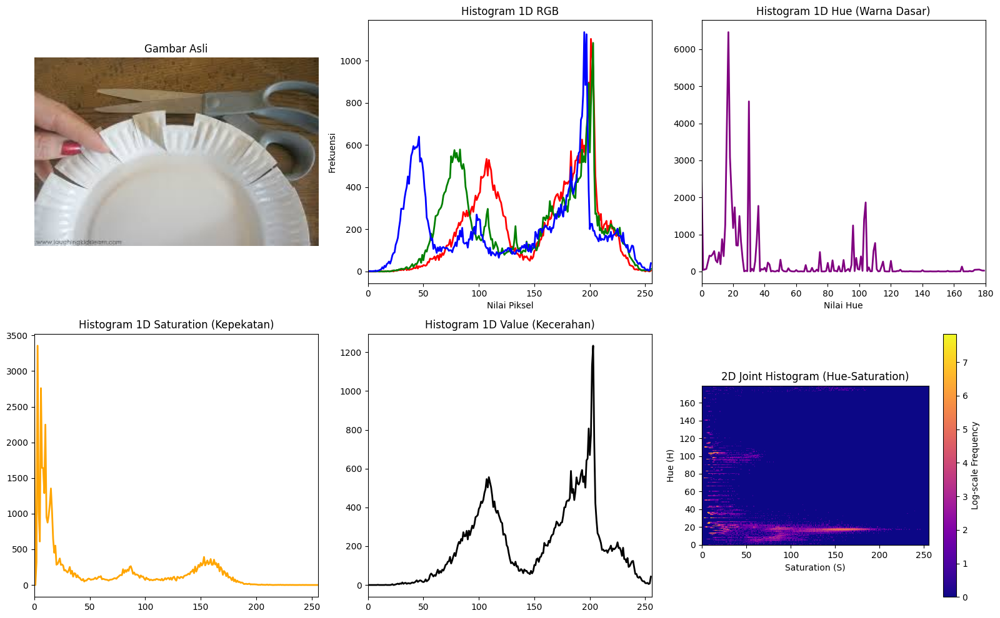

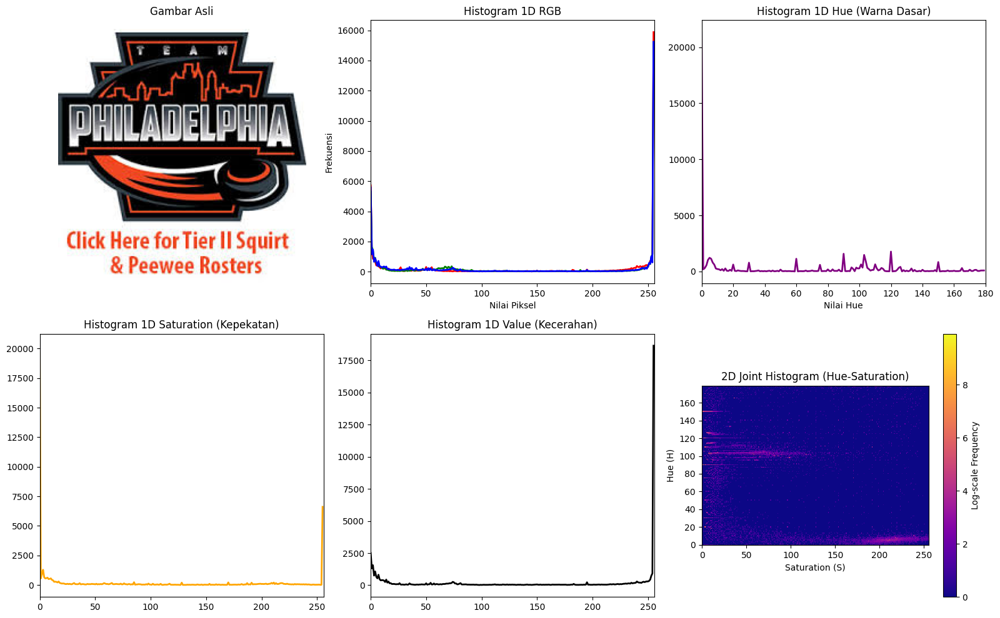

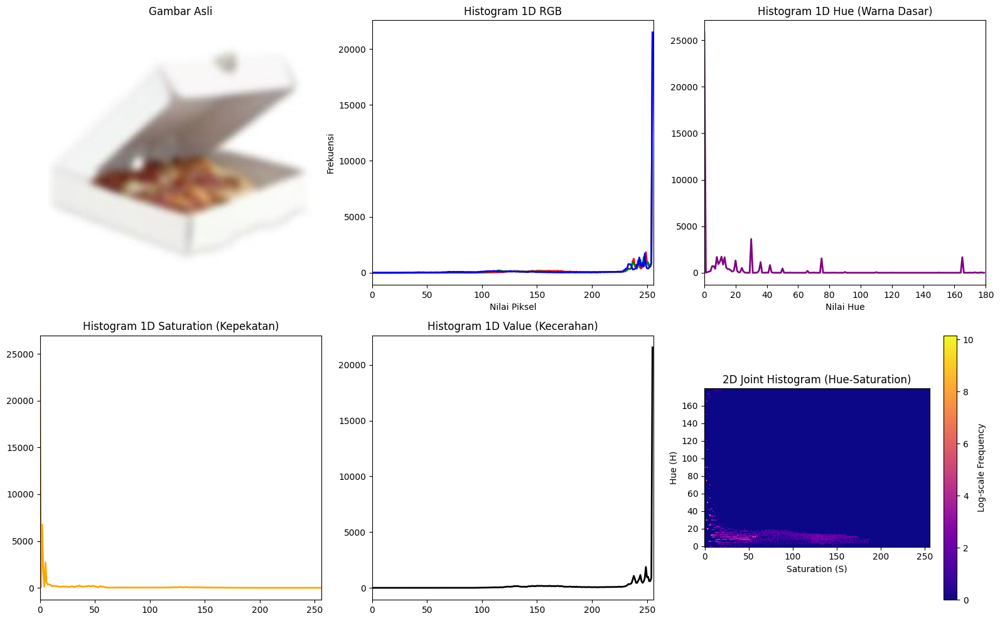

In [9]:
# Masukkan salah satu path file gambar di dataset Anda
p=3
for i in range(p):
    sample_path = df_train['file_path'].iloc[i]
    plot_color_histogram_analysis(sample_path)

In [10]:
import cv2
import numpy as np
import pandas as pd
import os
import time
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm
import matplotlib.pyplot as plt


# 1. Fungsi pengekstraksi GLCM (berada di tingkat modul agar bisa di-pickle untuk multiprocessing)
def extract_glcm_features(image_path):
    try:
        # Matikan multithreading internal OpenCV agar tidak bentrok dengan multiprocessing
        cv2.setNumThreads(0)
        
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Jarak d = 1 piksel dan 4 sudut (0, 45, 90, 135 derajat)
        distances = [1]
        angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
        
        # Hitung GLCM (levels=256 untuk gambar grayscale 8-bit)
        glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, 
                            symmetric=True, normed=True)
        
        feature_dict = {}
        props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
        
        # Ekstrak metrik dan hitung mean & std untuk menjaga kekebalan rotasi
        for prop in props:
            values = graycoprops(glcm, prop)[0] # Array berisi 4 nilai (1 per sudut)
            feature_dict[f'glcm_{prop}_mean'] = np.mean(values)
            feature_dict[f'glcm_{prop}_std'] = np.std(values)
            
        return feature_dict
        
    except Exception as e:
        return None

# 2. Fungsi Utama Ekstraksi Paralel Maksimal
def process_dataframe_glcm_optimized(df):
    paths = df['file_path'].tolist()
    
    num_cpus = multiprocessing.cpu_count()
    print(f"Memulai ekstraksi fitur GLCM pada {len(paths)} gambar menggunakan {num_cpus} Core CPU...")
    
    start_time = time.time()
    
    # ProcessPoolExecutor + chunksize=100 untuk performa I/O dan CPU maksimal
    with ProcessPoolExecutor(max_workers=num_cpus) as executor:
        results = list(tqdm(
            executor.map(extract_glcm_features, paths, chunksize=100), 
            total=len(paths)
        ))
        
    # Gabungkan hasil ekstraksi kembali ke DataFrame utama
    valid_results = [r for r in results if r is not None]
    valid_indices = [df.index[i] for i, r in enumerate(results) if r is not None]
    
    df_features = pd.DataFrame(valid_results, index=valid_indices)
    df_out = pd.concat([df.loc[valid_indices], df_features], axis=1)
    
    print(f"Ekstraksi GLCM selesai dalam {time.time() - start_time:.2f} detik!")
    return df_out


def plot_glcm_matrix_visualization(image_path):
    """
    Fungsi visualisasi untuk menunjukkan citra asli dan plot nilai GLCM Texture.
    """
    img = cv2.imread(image_path)
    if img is None:
        print("Gambar tidak ditemukan.")
        return
        
    features = extract_glcm_features(image_path)
    if features is None:
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Gambar Asli
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Gambar Asli")
    axes[0].axis('off')
    
    # 2. Visualisasi Nilai Fitur GLCM
    keys = ['glcm_contrast_mean', 'glcm_dissimilarity_mean', 'glcm_homogeneity_mean', 'glcm_energy_mean']
    labels = ['Contrast\n(Kekasaran)', 'Dissimilarity\n(Ketidakmiripan)', 'Homogeneity\n(Kemulusan)', 'Energy\n(Keteraturan)']
    values = [features[k] for k in keys]
    
    colors = ['firebrick', 'chocolate', 'seagreen', 'royalblue']
    bars = axes[1].bar(labels, values, color=colors, edgecolor='black')
    axes[1].set_title("Statistik Fitur Tekstur GLCM (Rata-rata Sudut)")
    axes[1].set_ylabel("Nilai Fitur")
    
    # Tuliskan nilai angkanya di atas bar
    for bar in bars:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
        
    plt.tight_layout()
    plt.show()


# Cara menjalankan di notebook Kaggle Anda:
df_train = process_dataframe_glcm_optimized(df_train)


Memulai ekstraksi fitur GLCM pada 26527 gambar menggunakan 4 Core CPU...


100%|██████████| 26527/26527 [06:24<00:00, 68.91it/s] 


Ekstraksi GLCM selesai dalam 385.26 detik!


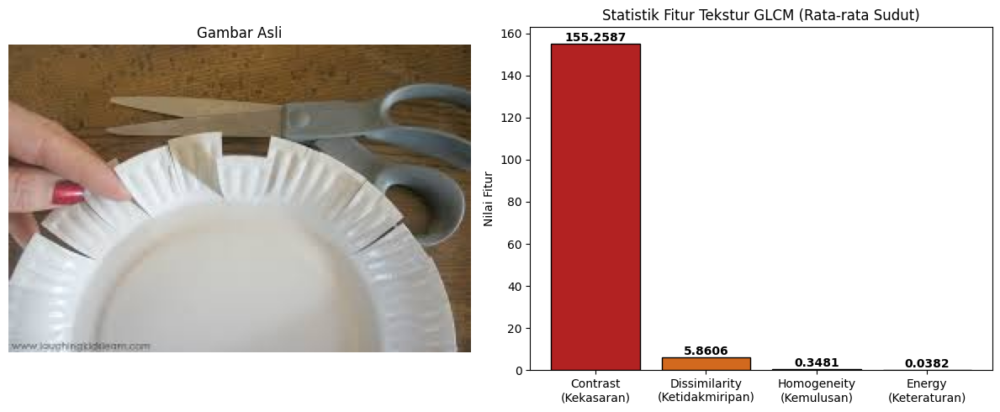

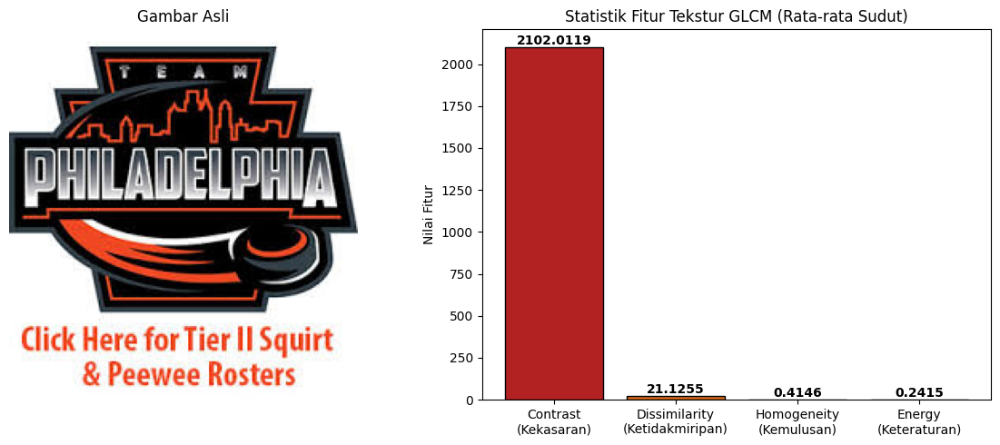

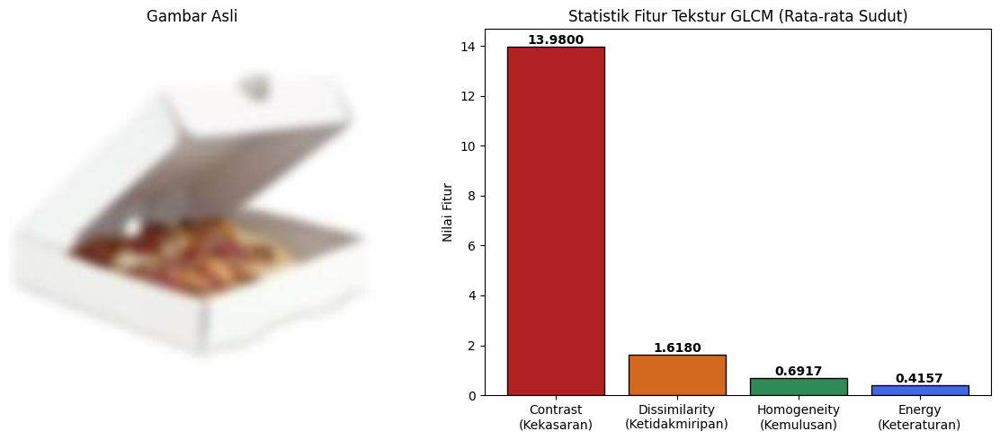

In [11]:
# Masukkan path gambar sampel Anda
p=3
for i in range(p):
    sample_path = df_train['file_path'].iloc[i]
    plot_glcm_matrix_visualization(sample_path)


In [12]:
import cv2
import numpy as np
import pandas as pd
import os
import time
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from skimage.feature import local_binary_pattern
from tqdm import tqdm

# 1. Fungsi Worker tingkat modul agar bisa di-pickle/di-serialize oleh multiprocessing
def extract_lbp_worker(args):
    image_path, P, R = args
    try:
        # Matikan internal threading OpenCV agar tidak bentrok dengan multiprocessing
        cv2.setNumThreads(0)
        
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Hitung LBP (Uniform)
        lbp = local_binary_pattern(gray, P, R, method='uniform')
        
        # Hitung Histogram LBP (10 bins untuk P=8)
        n_bins = int(P + 2)
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        
        # Simpan fitur
        feature_dict = {}
        for i in range(n_bins):
            feature_dict[f'lbp_bin_{i}'] = hist[i]
            
        feature_dict['lbp_mean'] = np.mean(lbp)
        feature_dict['lbp_std'] = np.std(lbp)
        feature_dict['lbp_entropy'] = -np.sum(hist * np.log2(hist + 1e-7))
        
        return feature_dict
    except Exception:
        return None

# 2. Fungsi Utama Ekstraksi Paralel Maksimal
def process_dataframe_lbp_optimized(df, P=8, R=1):
    paths = df['file_path'].tolist()
    # Bungkus argumen menjadi tuple list
    worker_args = [(p, P, R) for p in paths]
    
    num_cpus = multiprocessing.cpu_count()
    print(f"Memulai ekstraksi LBP pada {len(paths)} gambar menggunakan {num_cpus} Core CPU...")
    
    start_time = time.time()
    # Menggunakan ProcessPool & chunksize untuk efisiensi transfer data
    with ProcessPoolExecutor(max_workers=num_cpus) as executor:
        results = list(tqdm(
            executor.map(extract_lbp_worker, worker_args, chunksize=100), 
            total=len(paths)
        ))
        
    valid_results = [r for r in results if r is not None]
    valid_indices = [df.index[i] for i, r in enumerate(results) if r is not None]
    
    df_features = pd.DataFrame(valid_results, index=valid_indices)
    df_out = pd.concat([df.loc[valid_indices], df_features], axis=1)
    
    print(f"Ekstraksi LBP selesai dalam {time.time() - start_time:.2f} detik!")
    return df_out

# Cara menjalankan di notebook Kaggle Anda:
df_train = process_dataframe_lbp_optimized(df_train, P=8, R=1)


Memulai ekstraksi LBP pada 26527 gambar menggunakan 4 Core CPU...


100%|██████████| 26527/26527 [09:54<00:00, 44.64it/s] 


Ekstraksi LBP selesai dalam 594.60 detik!


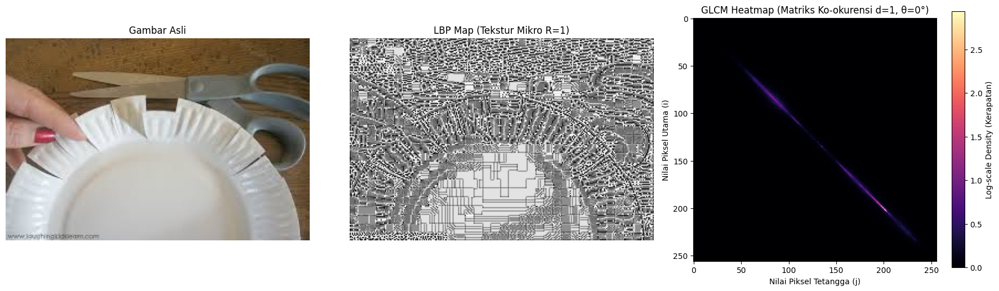

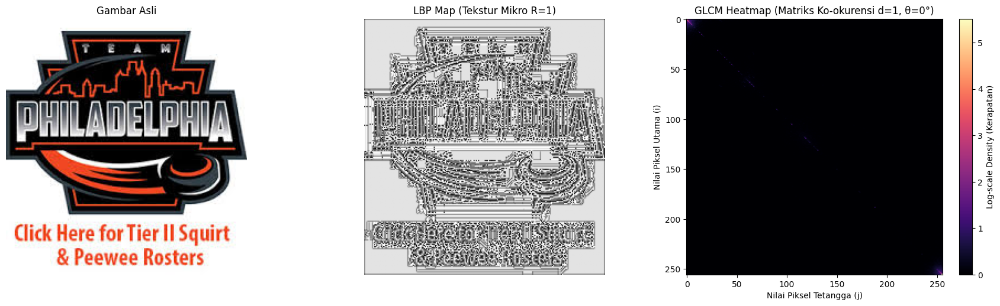

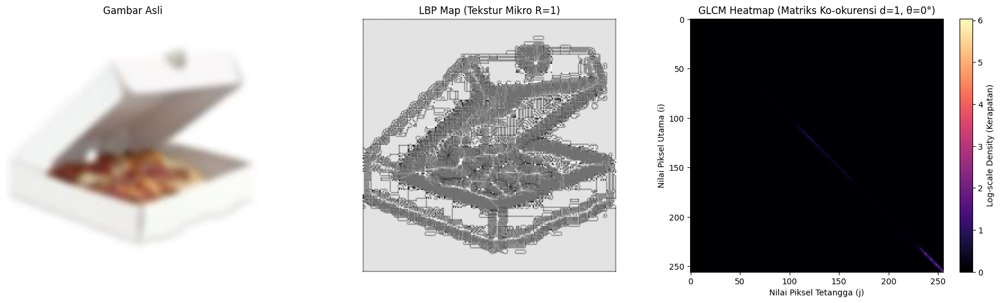

In [13]:
def plot_texture_maps(image_path, P=8, R=1):
    """
    Visualisasi Peta Tekstur (Texture Maps) dari Gambar Asli:
    1. LBP Map: Menunjukkan peta spasial tekstur mikro (2D Image).
    2. GLCM Heatmap: Menunjukkan matriks ko-okurensi 2D intensitas piksel (256x256).
    """
    img = cv2.imread(image_path)
    if img is None:
        print("Gambar tidak ditemukan.")
        return
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. HITUNG LBP MAP
    lbp_map = local_binary_pattern(gray, P, R, method='uniform')
    
    # 2. HITUNG GLCM MATRIX (Jarak d=1, Sudut 0 derajat)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    glcm_matrix = glcm[:, :, 0, 0] # Mengambil matriks 2D ukuran 256x256
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Subplot 1: Gambar Asli
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Gambar Asli", fontsize=12)
    axes[0].axis('off')
    
    # Subplot 2: LBP Map (Visualisasi Tekstur Mikro)
    # Menggunakan colormap 'gray' untuk melihat peta abu-abu tekstur murni
    axes[1].imshow(lbp_map, cmap='gray')
    axes[1].set_title(f"LBP Map (Tekstur Mikro R={R})", fontsize=12)
    axes[1].axis('off')
    
    # Subplot 3: GLCM Heatmap (Matriks Distribusi Spasial)
    # Menggunakan log scale log1p agar perbedaan frekuensi kecil tetap terdeteksi secara visual
    log_glcm = np.log1p(glcm_matrix * 1000) 
    im = axes[2].imshow(log_glcm, cmap='magma')
    axes[2].set_title("GLCM Heatmap (Matriks Ko-okurensi d=1, θ=0°)", fontsize=12)
    axes[2].set_xlabel("Nilai Piksel Tetangga (j)")
    axes[2].set_ylabel("Nilai Piksel Utama (i)")
    
    # Tambahkan colorbar di sebelah kanan heatmap GLCM
    fig.colorbar(im, ax=axes[2], label='Log-scale Density (Kerapatan)')
    
    plt.tight_layout()
    plt.show()

# Panggil fungsi ini untuk melihat peta visual LBP & GLCM:
p=3
for i in range(p):
    sample_path = df_train['file_path'].iloc[i]
    plot_texture_maps(sample_path)


In [14]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image
import imagehash
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
from tqdm import tqdm

# Coba gunakan PyTorch jika tersedia di Kaggle untuk akselerasi GPU
try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

TRAIN_DIR = "/kaggle/input/datasets/muhammadraiyansani/bdc-2-dataset/BDC2026-20260703T023220Z-3-001/BDC2026/train"
HASH_DB_PATH = "train_image_phashes.csv"
MAX_ANALYSIS_DIST = 4

def get_image_files(directory):
    records = []
    if not os.path.exists(directory):
        return pd.DataFrame()
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                records.append({
                    "file_path": os.path.join(root, file),
                    "filename": file,
                    "label": os.path.basename(root)
                })
    return pd.DataFrame(records)

def compute_single_phash(file_path):
    try:
        with Image.open(file_path) as img:
            return str(imagehash.phash(img))
    except Exception:
        return None

def generate_and_save_phashes():
    df = get_image_files(TRAIN_DIR)
    if df.empty:
        return None
    num_cpus = multiprocessing.cpu_count()
    print(f"Mengekstrak pHash pada {len(df)} gambar menggunakan {num_cpus} Core CPU...")
    paths = df['file_path'].tolist()
    with ProcessPoolExecutor(max_workers=num_cpus) as executor:
        hashes = list(tqdm(executor.map(compute_single_phash, paths, chunksize=100), total=len(paths)))
    df['phash'] = hashes
    df = df.dropna(subset=['phash']).reset_index(drop=True)
    df.to_csv(HASH_DB_PATH, index=False)
    return df

def analyze_hamming_and_duplicates(df):
    print("\nMengonversi hash hex menjadi matriks biner...")
    hash_objects = [imagehash.hex_to_hash(h) for h in df['phash']]
    hashes_bool = np.array([h.hash.flatten() for h in hash_objects])
    
    # Konversi ke float32 representasi -1.0 dan 1.0
    H = np.where(hashes_bool, 1.0, -1.0).astype(np.float32)
    
    device_name = "CPU"
    use_gpu = HAS_TORCH and torch.cuda.is_available()
    
    start_time = time.time()
    if use_gpu:
        device_name = "GPU (CUDA)"
        H_tensor = torch.tensor(H).cuda()
        P = torch.matmul(H_tensor, H_tensor.T) # Matmul super cepat di GPU
        D = (64 - P) / 2
        upper_mask = torch.triu(torch.ones_like(D), diagonal=1) > 0
        idx_a, idx_b = torch.where((D <= MAX_ANALYSIS_DIST) & upper_mask)
        idx_a, idx_b = idx_a.cpu().numpy(), idx_b.cpu().numpy()
        distances = D[idx_a, idx_b].cpu().numpy().astype(int)
    else:
        device_name = "CPU (BLAS)"
        P = np.dot(H, H.T) # Matmul multi-threaded di CPU
        D = (64 - P) / 2
        idx_a, idx_b = np.where((D <= MAX_ANALYSIS_DIST) & (np.triu(np.ones_like(D), k=1) > 0))
        distances = D[idx_a, idx_b].astype(int)
        
    print(f"Perbandingan 350+ juta pasangan selesai dalam {time.time() - start_time:.2f} detik via {device_name}.")
    
    # Tampilkan Rekap Jarak
    dist_distribution = {d: 0 for d in range(MAX_ANALYSIS_DIST + 1)}
    for d in distances:
        if d in dist_distribution:
            dist_distribution[d] += 1
    print("\n--- DISTRIBUSI KEMIRIPAN HAMMING ---")
    for dist, count in dist_distribution.items():
        print(f"  Jarak {dist}: {count} pasangan")
        
    # Deteksi Konflik Label
    df_dups = pd.DataFrame({
        "file_a": df.iloc[idx_a]['file_path'].values,
        "file_b": df.iloc[idx_b]['file_path'].values,
        "label_a": df.iloc[idx_a]['label'].values,
        "label_b": df.iloc[idx_b]['label'].values,
        "hamming_dist": distances
    })
    df_dups['is_conflict'] = df_dups['label_a'] != df_dups['label_b']
    conflicts = df_dups[df_dups['is_conflict'] == True]
    
    print(f"\nTotal Duplikat (dist <= {MAX_ANALYSIS_DIST}): {len(df_dups)}")
    print(f"Total KONFLIK LABEL (Gambar mirip tapi beda kelas): {len(conflicts)}")
    
    if not conflicts.empty:
        conflicts_sorted = conflicts.sort_values(by='hamming_dist')
        print("\n--- CONTOH KONFLIK LABEL TERATAS ---")
        for idx, row in conflicts_sorted.head(10).iterrows():
            print(f"Jarak {row['hamming_dist']} | {row['label_a']}: {os.path.basename(row['file_a'])} vs {row['label_b']}: {os.path.basename(row['file_b'])}")
        conflicts_sorted.to_csv("conflicting_labeled_duplicates.csv", index=False)
        print("\nHasil lengkap disimpan ke 'conflicting_labeled_duplicates.csv'!")

if __name__ == "__main__":
    if os.path.exists(HASH_DB_PATH):
        df_hashes = pd.read_csv(HASH_DB_PATH)
    else:
        df_hashes = generate_and_save_phashes()
    
    if df_hashes is not None:
        analyze_hamming_and_duplicates(df_hashes)
        
        # GABUNGKAN PHASH KE DF_TRAIN UTAMA
        df_phash_only = df_hashes[['file_path', 'phash']]
        df_train = df_train.merge(df_phash_only, on="file_path", how="left")
        print("Kolom pHash berhasil digabungkan ke df_train!")



Mengekstrak pHash pada 26527 gambar menggunakan 4 Core CPU...


100%|██████████| 26527/26527 [00:39<00:00, 664.91it/s] 



Mengonversi hash hex menjadi matriks biner...
Perbandingan 350+ juta pasangan selesai dalam 11.41 detik via CPU (BLAS).

--- DISTRIBUSI KEMIRIPAN HAMMING ---
  Jarak 0: 361 pasangan
  Jarak 1: 0 pasangan
  Jarak 2: 99 pasangan
  Jarak 3: 0 pasangan
  Jarak 4: 88 pasangan

Total Duplikat (dist <= 4): 548
Total KONFLIK LABEL (Gambar mirip tapi beda kelas): 10

--- CONTOH KONFLIK LABEL TERATAS ---
Jarak 0 | 0_Recyclable: R_799.jpg vs 2_Organic: O_8873.jpg
Jarak 2 | 0_Recyclable: R_3909.jpg vs 2_Organic: O_550.jpg
Jarak 4 | 0_Recyclable: R_3407.jpg vs 2_Organic: O_1599.jpg
Jarak 4 | 0_Recyclable: R_3917.jpg vs 2_Organic: O_550.jpg
Jarak 4 | 0_Recyclable: R_8601.jpg vs 1_Electronic: Washing_Machine_4.jpg
Jarak 4 | 0_Recyclable: R_3468.jpg vs 2_Organic: O_1599.jpg
Jarak 4 | 0_Recyclable: R_9497.jpg vs 2_Organic: O_9193.jpg
Jarak 4 | 0_Recyclable: R_5107.jpg vs 1_Electronic: Washing_Machine_4.jpg
Jarak 4 | 0_Recyclable: R_5696.jpg vs 2_Organic: O_1599.jpg
Jarak 4 | 1_Electronic: 67.waste-400

Mencari kandidat pasangan dengan pHash <= 4...
Ditemukan 548 kandidat pasangan dengan pHash <= 4.
Menghitung dHash untuk 998 gambar kandidat...

🎨 EVALUASI VISUAL DHASH RANGES (0 s.d. 4)

👉 [Jarak dHash: 0] Ditemukan 268 pasangan.


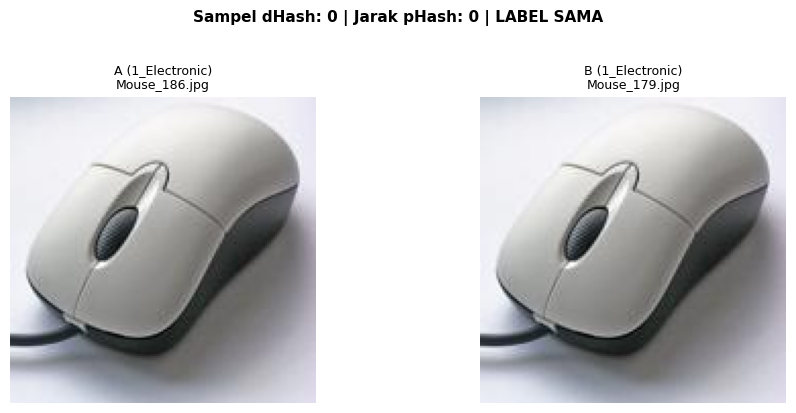

------------------------------------------------------------


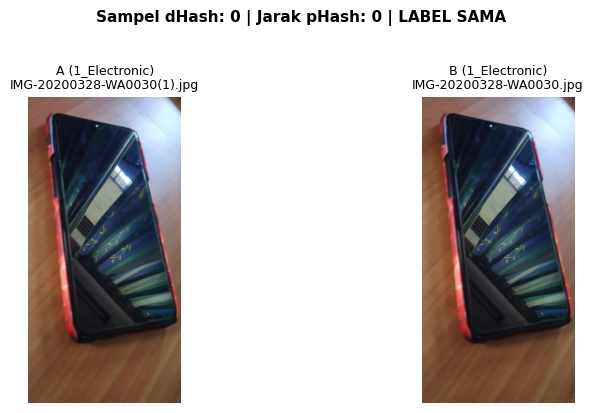

------------------------------------------------------------


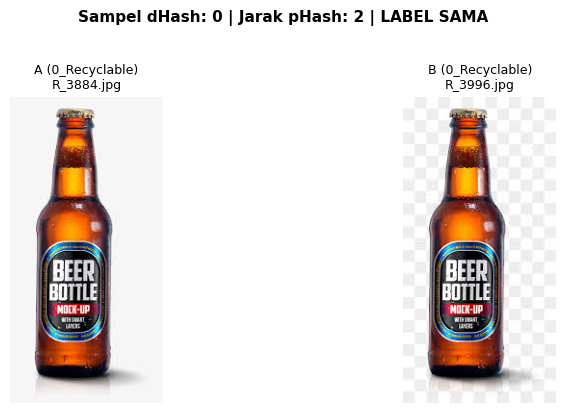

------------------------------------------------------------

👉 [Jarak dHash: 1] Ditemukan 96 pasangan.


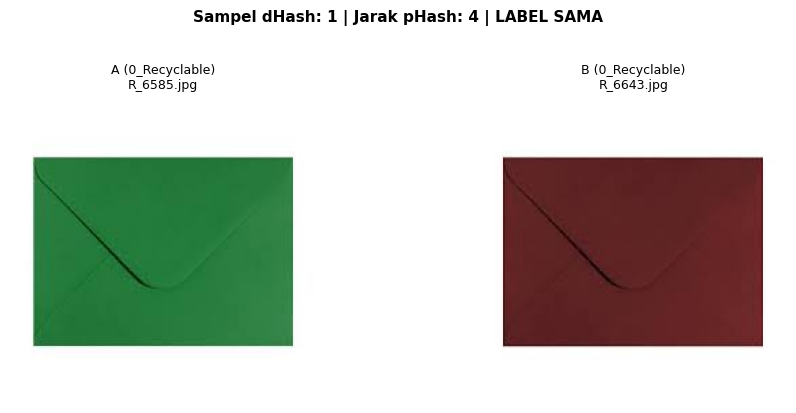

------------------------------------------------------------


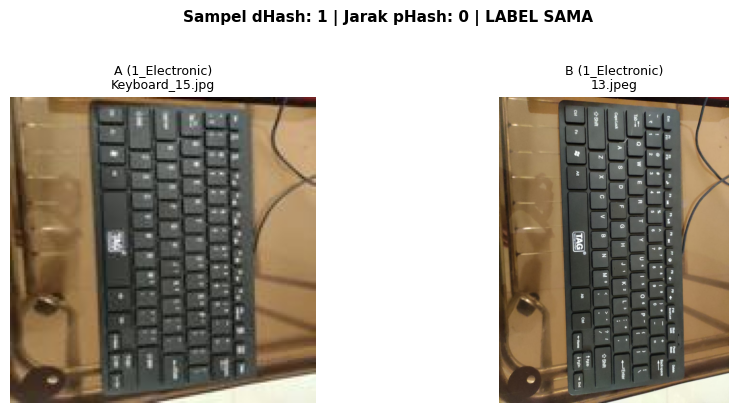

------------------------------------------------------------


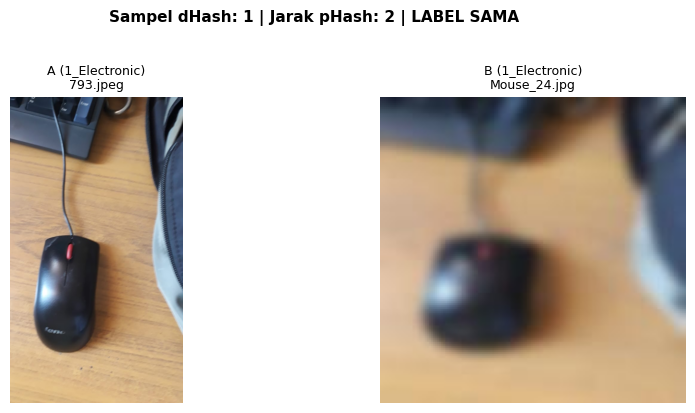

------------------------------------------------------------

👉 [Jarak dHash: 2] Ditemukan 55 pasangan.


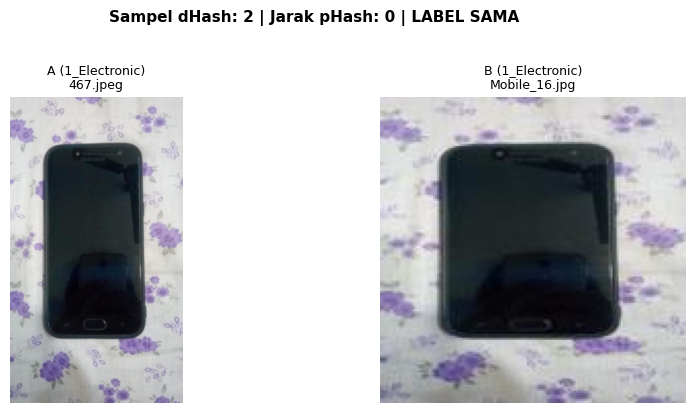

------------------------------------------------------------


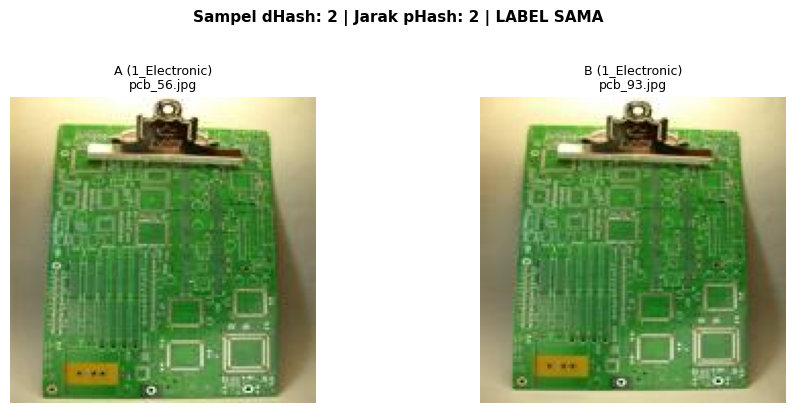

------------------------------------------------------------


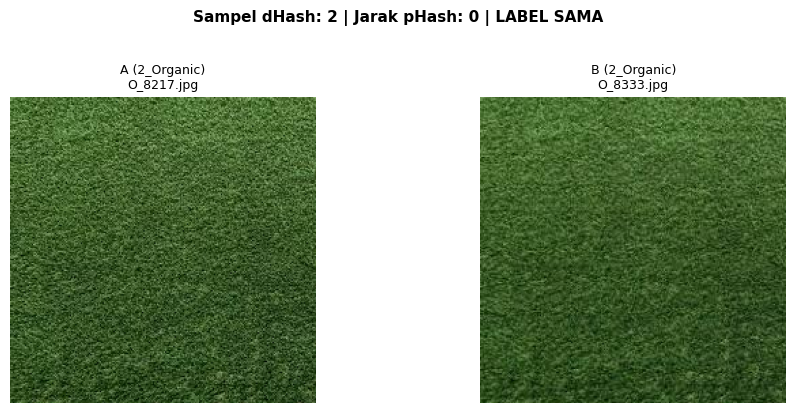

------------------------------------------------------------

👉 [Jarak dHash: 3] Ditemukan 21 pasangan.


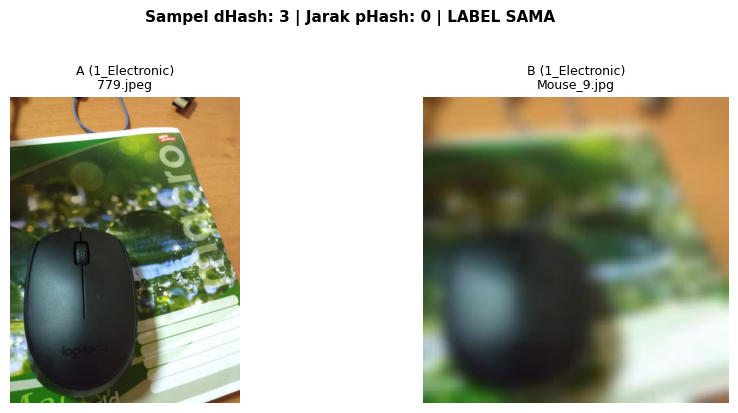

------------------------------------------------------------


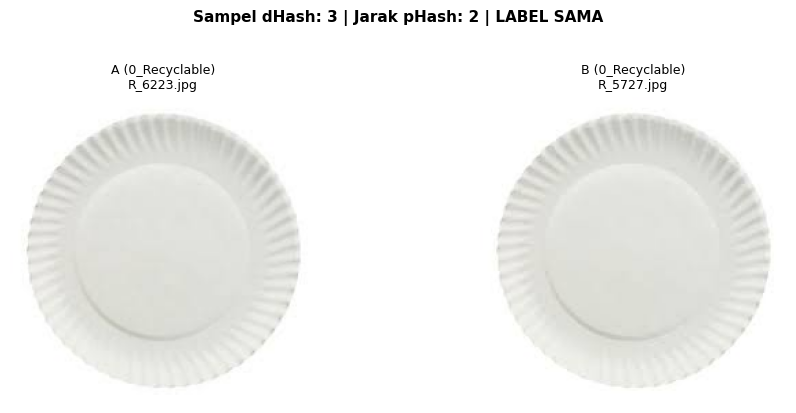

------------------------------------------------------------


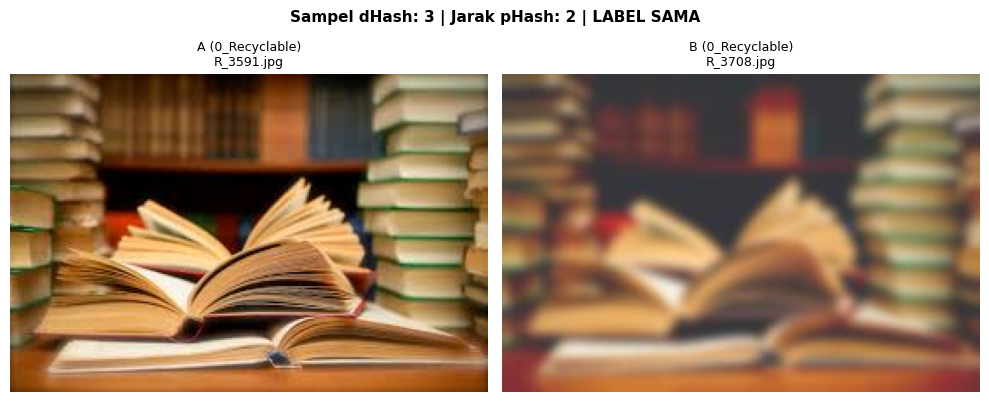

------------------------------------------------------------

👉 [Jarak dHash: 4] Ditemukan 15 pasangan.


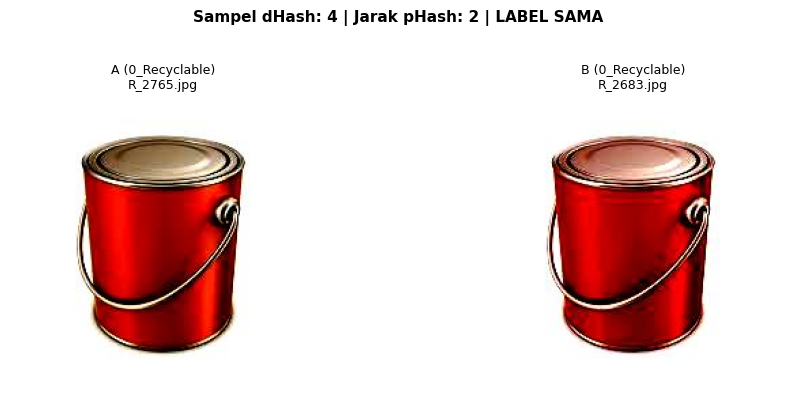

------------------------------------------------------------


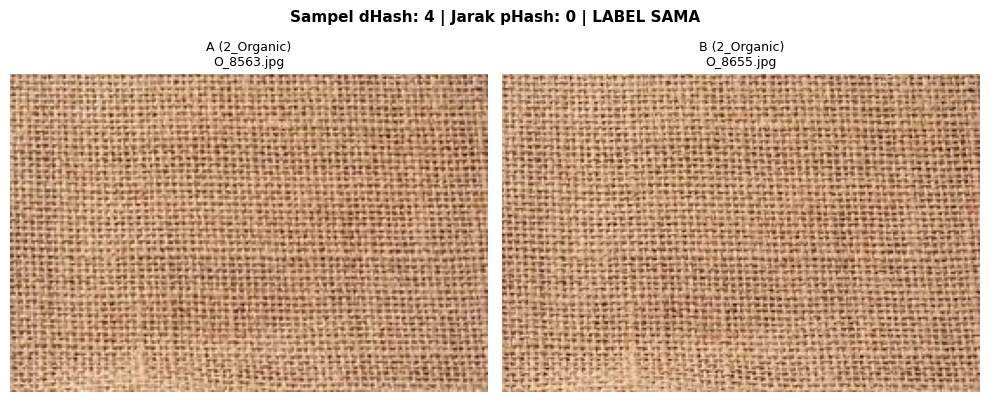

------------------------------------------------------------


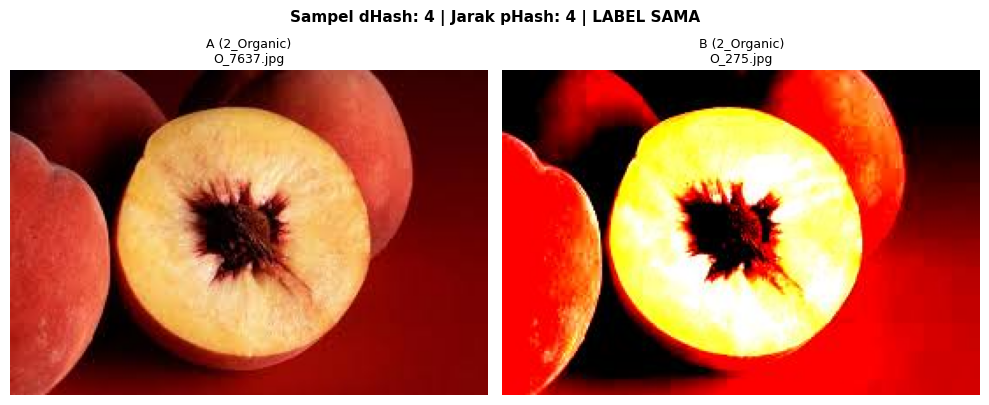

------------------------------------------------------------


In [15]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imagehash
from PIL import Image
from collections import defaultdict

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

def analyze_and_plot_dhash_ranges(hash_csv_path="train_image_phashes.csv", max_phash_dist=4, num_samples=3):
    if not os.path.exists(hash_csv_path):
        print(f"File CSV '{hash_csv_path}' tidak ditemukan. Jalankan ekstraksi pHash terlebih dahulu.")
        return
        
    df = pd.read_csv(hash_csv_path)
    n = len(df)
    
    # 1. Hitung Jarak pHash secara cepat dengan GPU/CPU
    hash_objects = [imagehash.hex_to_hash(h) for h in df['phash']]
    hashes_bool = np.array([h.hash.flatten() for h in hash_objects])
    H = np.where(hashes_bool, 1.0, -1.0).astype(np.float32)
    
    use_gpu = HAS_TORCH and torch.cuda.is_available()
    print("Mencari kandidat pasangan dengan pHash <= 4...")
    if use_gpu:
        H_tensor = torch.tensor(H).cuda()
        P = torch.matmul(H_tensor, H_tensor.T)
        D = (64 - P) / 2
        upper_mask = torch.triu(torch.ones_like(D), diagonal=1) > 0
        idx_a, idx_b = torch.where((D <= max_phash_dist) & upper_mask)
        idx_a = idx_a.cpu().numpy()
        idx_b = idx_b.cpu().numpy()
        phash_distances = D[idx_a, idx_b].cpu().numpy().astype(int)
    else:
        P = np.dot(H, H.T)
        D = (64 - P) / 2
        idx_a, idx_b = np.where((D <= max_phash_dist) & (np.triu(np.ones_like(D), k=1) > 0))
        phash_distances = D[idx_a, idx_b].astype(int)
        
    total_candidates = len(idx_a)
    print(f"Ditemukan {total_candidates} kandidat pasangan dengan pHash <= {max_phash_dist}.")
    
    if total_candidates == 0:
        return
        
    # 2. Hitung dHash hanya untuk gambar kandidat unik (Sangat hemat RAM & waktu!)
    unique_candidate_indices = np.unique(np.concatenate([idx_a, idx_b]))
    print(f"Menghitung dHash untuk {len(unique_candidate_indices)} gambar kandidat...")
    
    dhash_map = {}
    for idx in unique_candidate_indices:
        file_path = df.iloc[idx]['file_path']
        try:
            with Image.open(file_path) as img:
                dhash_map[idx] = imagehash.dhash(img)
        except Exception:
            dhash_map[idx] = None
            
    # 3. Kelompokkan pasangan berdasarkan jarak dHash
    pairs_by_dhash = defaultdict(list)
    for k in range(total_candidates):
        i = idx_a[k]
        j = idx_b[k]
        dh_a = dhash_map[i]
        dh_b = dhash_map[j]
        
        if dh_a is not None and dh_b is not None:
            dhash_dist = dh_a - dh_b
            pairs_by_dhash[dhash_dist].append({
                "file_a": df.iloc[i]['file_path'],
                "file_b": df.iloc[j]['file_path'],
                "label_a": df.iloc[i]['label'],
                "label_b": df.iloc[j]['label'],
                "phash_dist": phash_distances[k],
                "dhash_dist": dhash_dist
            })
            
    # 4. Plot Sampel Gambar untuk setiap rentang jarak dHash (0 s.d. 4)
    print("\n" + "="*80)
    print("🎨 EVALUASI VISUAL DHASH RANGES (0 s.d. 4)")
    print("="*80)
    
    np.random.seed(42)  # Konstan agar hasil awal dapat diperbandingkan
    
    for target_dhash in range(5):
        pairs_list = pairs_by_dhash[target_dhash]
        total_pairs = len(pairs_list)
        print(f"\n👉 [Jarak dHash: {target_dhash}] Ditemukan {total_pairs} pasangan.")
        
        if total_pairs == 0:
            print("  (Tidak ada pasangan gambar)")
            continue
            
        sample_indices = np.random.choice(total_pairs, min(num_samples, total_pairs), replace=False)
        for s_idx in sample_indices:
            pair = pairs_list[s_idx]
            file_a = pair['file_a']
            file_b = pair['file_b']
            label_a = pair['label_a']
            label_b = pair['label_b']
            p_dist = pair['phash_dist']
            
            img_a = cv2.imread(file_a)
            img_b = cv2.imread(file_b)
            if img_a is None or img_b is None:
                continue
                
            img_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
            img_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)
            
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].imshow(img_a)
            axes[0].set_title(f"A ({label_a})\n{os.path.basename(file_a)}", fontsize=9)
            axes[0].axis('off')
            axes[1].imshow(img_b)
            axes[1].set_title(f"B ({label_b})\n{os.path.basename(file_b)}", fontsize=9)
            axes[1].axis('off')
            
            is_conflict = label_a != label_b
            title_color = 'red' if is_conflict else 'black'
            
            plt.suptitle(
                f"Sampel dHash: {target_dhash} | Jarak pHash: {p_dist} | "
                f"{'⚠️ BEDA LABEL' if is_conflict else 'LABEL SAMA'}",
                fontsize=11, fontweight='bold', color=title_color, y=1.02
            )
            plt.tight_layout()
            plt.show()
            print("-" * 60)

# Jalankan analisis visual dHash
analyze_and_plot_dhash_ranges("train_image_phashes.csv", max_phash_dist=4, num_samples=3)


Memuat 26527 gambar dari database pHash...
Mencari pasangan dengan pHash <= 7...
Ditemukan 783 kandidat pasangan dengan pHash <= 7.
Menghitung dHash untuk 1303 gambar kandidat...

📊 MATRIKS JUMLAH KONFLIK LINTAS KELAS (pHash vs dHash)
 pHash  dH 0  dH 1  dH 2  dH 3  dH 4  dH 5  dH 6  dH 7  dH >= 8
     0     1     0     0     0     0     0     0     0        0
     1     0     0     0     0     0     0     0     0        0
     2     0     0     0     0     0     0     0     0        1
     3     0     0     0     0     0     0     0     0        0
     4     0     0     1     0     0     0     0     0        7
     5     0     0     0     0     0     0     0     0        0
     6     1     0     0     1     0     1     2     2       44
     7     0     0     0     0     0     0     0     0        0

🎨 VISUALISASI PASANGAN KONFLIK LINTAS KELAS (dHash <= 7)
Ditemukan 9 pasangan konflik dengan dHash <= 7 untuk divalidasi:



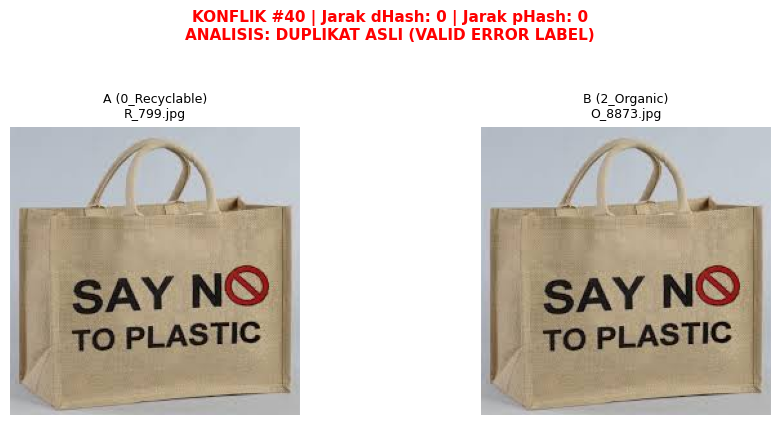

--------------------------------------------------------------------------------


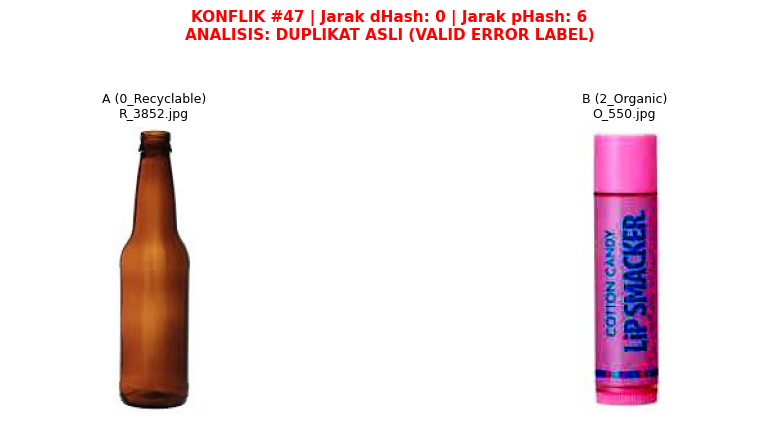

--------------------------------------------------------------------------------


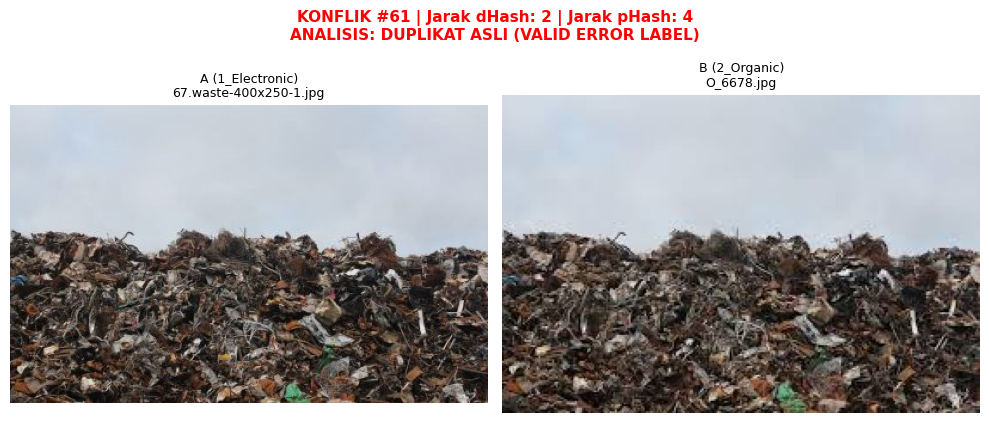

--------------------------------------------------------------------------------


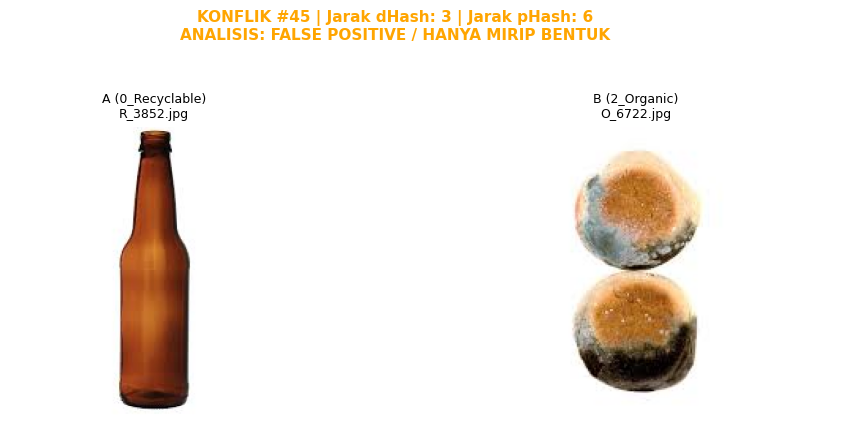

--------------------------------------------------------------------------------


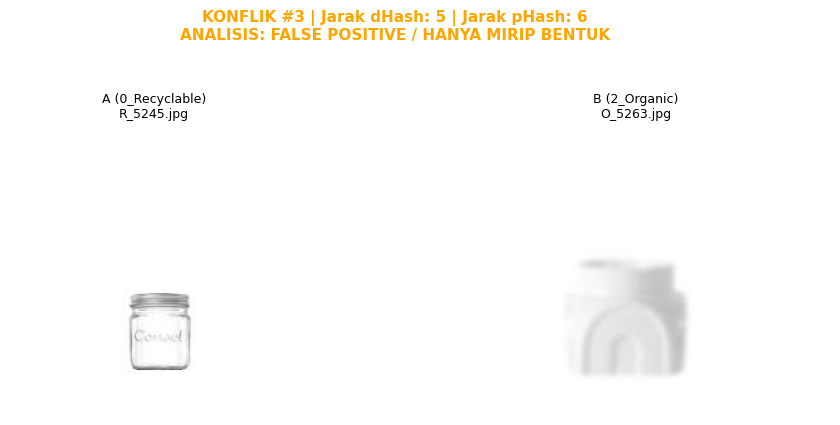

--------------------------------------------------------------------------------


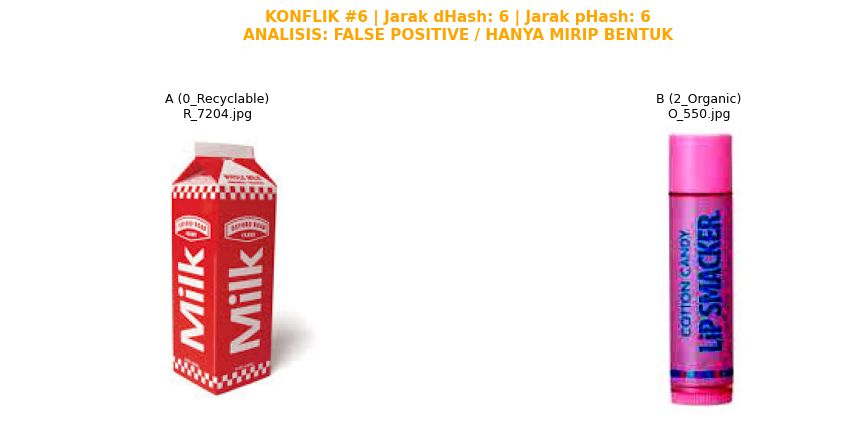

--------------------------------------------------------------------------------


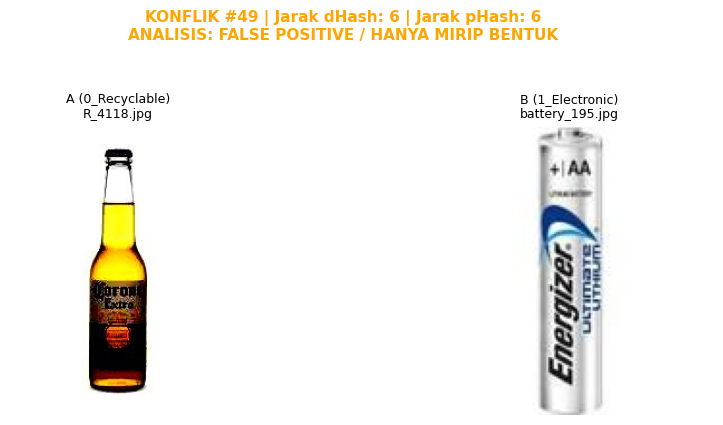

--------------------------------------------------------------------------------


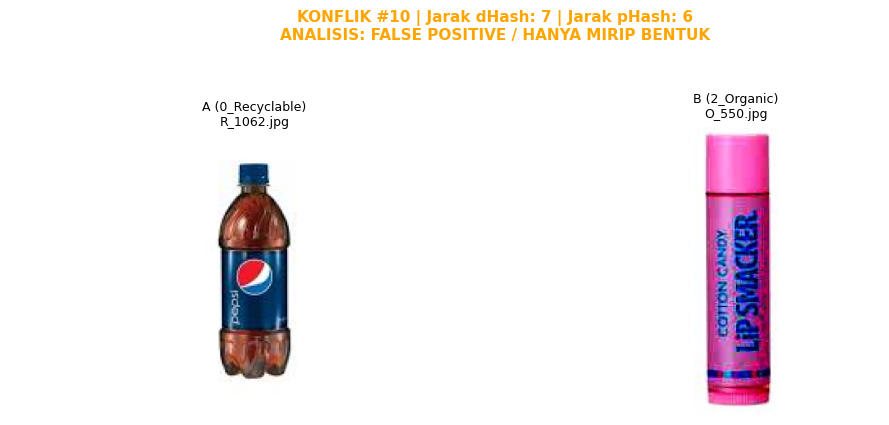

--------------------------------------------------------------------------------


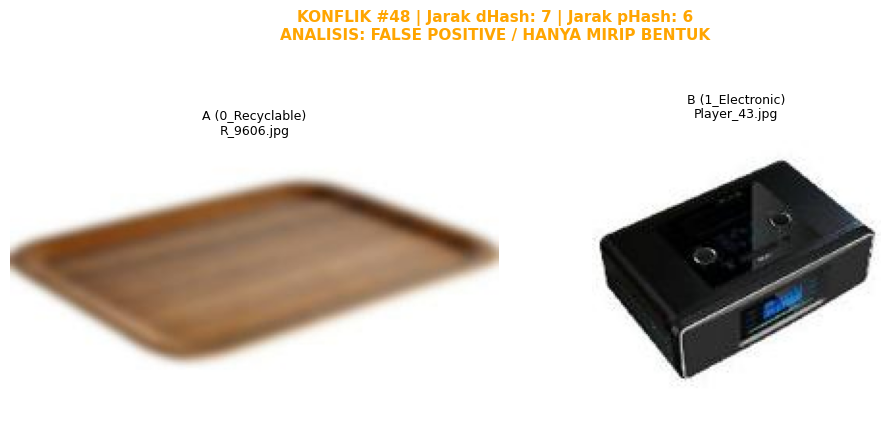

--------------------------------------------------------------------------------


In [16]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imagehash
from PIL import Image
from collections import defaultdict

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

def analyze_crossclass_combinations_all(hash_csv_path="train_image_phashes.csv", max_dist=7, max_dhash_to_plot=7):
    """
    Mendeteksi konflik lintas kelas (label berbeda) untuk seluruh kombinasi jarak pHash (0 s.d. 7)
    dan memvisualisasikan seluruh pasangan yang memiliki dHash <= max_dhash_to_plot (default 7).
    """
    if not os.path.exists(hash_csv_path):
        print(f"File CSV '{hash_csv_path}' tidak ditemukan. Jalankan ekstraksi pHash dahulu.")
        return
        
    df = pd.read_csv(hash_csv_path)
    n = len(df)
    print(f"Memuat {n} gambar dari database pHash...")
    
    # 1. Hitung Jarak pHash (GPU/CPU)
    hash_objects = [imagehash.hex_to_hash(h) for h in df['phash']]
    hashes_bool = np.array([h.hash.flatten() for h in hash_objects])
    H = np.where(hashes_bool, 1.0, -1.0).astype(np.float32)
    
    use_gpu = HAS_TORCH and torch.cuda.is_available()
    print(f"Mencari pasangan dengan pHash <= {max_dist}...")
    if use_gpu:
        H_tensor = torch.tensor(H).cuda()
        P = torch.matmul(H_tensor, H_tensor.T)
        D = (64 - P) / 2
        upper_mask = torch.triu(torch.ones_like(D), diagonal=1) > 0
        idx_a, idx_b = torch.where((D <= max_dist) & upper_mask)
        idx_a = idx_a.cpu().numpy()
        idx_b = idx_b.cpu().numpy()
        phash_distances = D[idx_a, idx_b].cpu().numpy().astype(int)
    else:
        P = np.dot(H, H.T)
        D = (64 - P) / 2
        idx_a, idx_b = np.where((D <= max_dist) & (np.triu(np.ones_like(D), k=1) > 0))
        phash_distances = D[idx_a, idx_b].astype(int)
        
    total_candidates = len(idx_a)
    print(f"Ditemukan {total_candidates} kandidat pasangan dengan pHash <= {max_dist}.")
    
    # 2. Hitung dHash on-the-fly hanya untuk gambar kandidat unik
    unique_candidate_indices = np.unique(np.concatenate([idx_a, idx_b]))
    print(f"Menghitung dHash untuk {len(unique_candidate_indices)} gambar kandidat...")
    
    dhash_map = {}
    for idx in unique_candidate_indices:
        file_path = df.iloc[idx]['file_path']
        try:
            with Image.open(file_path) as img:
                dhash_map[idx] = imagehash.dhash(img)
        except Exception:
            dhash_map[idx] = None
            
    # 3. Filter Konflik Lintas Kelas & Catat Frekuensi
    conflict_records = []
    combination_counts = defaultdict(int)
    
    for k in range(total_candidates):
        i = idx_a[k]
        j = idx_b[k]
        
        # Beda label
        if df.iloc[i]['label'] != df.iloc[j]['label']:
            dh_a = dhash_map[i]
            dh_b = dhash_map[j]
            if dh_a is not None and dh_b is not None:
                dhash_dist = dh_a - dh_b
                combination_counts[(phash_distances[k], dhash_dist)] += 1
                conflict_records.append({
                    "file_a": df.iloc[i]['file_path'],
                    "file_b": df.iloc[j]['file_path'],
                    "label_a": df.iloc[i]['label'],
                    "label_b": df.iloc[j]['label'],
                    "phash_dist": phash_distances[k],
                    "dhash_dist": dhash_dist
                })
                
    df_conflicts = pd.DataFrame(conflict_records)
    
    # 4. Cetak Tabel Matriks Cross-Tabulation
    print("\n" + "="*90)
    print("📊 MATRIKS JUMLAH KONFLIK LINTAS KELAS (pHash vs dHash)")
    print("="*90)
    
    matrix_data = []
    for p_val in range(max_dist + 1):
        row_data = {"pHash": p_val}
        for d_val in range(max_dhash_to_plot + 1):
            row_data[f"dH {d_val}"] = combination_counts[(p_val, d_val)]
        row_data[f"dH >= {max_dhash_to_plot + 1}"] = sum(combination_counts[(p_val, d)] for d in range(max_dhash_to_plot + 1, 65) if (p_val, d) in combination_counts)
        matrix_data.append(row_data)
        
    df_matrix = pd.DataFrame(matrix_data)
    print(df_matrix.to_string(index=False))
    
    # 5. Visualisasi Detail Pasangan dengan dHash <= max_dhash_to_plot
    print("\n" + "="*90)
    print(f"🎨 VISUALISASI PASANGAN KONFLIK LINTAS KELAS (dHash <= {max_dhash_to_plot})")
    print("="*90)
    
    if df_conflicts.empty:
        print("Tidak ada konflik ditemukan.")
        return
        
    close_conflicts = df_conflicts[df_conflicts['dhash_dist'] <= max_dhash_to_plot].sort_values(by=['dhash_dist', 'phash_dist'])
    print(f"Ditemukan {len(close_conflicts)} pasangan konflik dengan dHash <= {max_dhash_to_plot} untuk divalidasi:\n")
    
    for idx, row in close_conflicts.iterrows():
        file_a = row['file_a']
        file_b = row['file_b']
        label_a = row['label_a']
        label_b = row['label_b']
        p_dist = row['phash_dist']
        d_dist = row['dhash_dist']
        
        img_a = cv2.imread(file_a)
        img_b = cv2.imread(file_b)
        if img_a is None or img_b is None:
            continue
            
        img_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
        img_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(img_a)
        axes[0].set_title(f"A ({label_a})\n{os.path.basename(file_a)}", fontsize=9)
        axes[0].axis('off')
        axes[1].imshow(img_b)
        axes[1].set_title(f"B ({label_b})\n{os.path.basename(file_b)}", fontsize=9)
        axes[1].axis('off')
        
        # Penilaian visual otomatis berdasarkan hasil analisis gabungan:
        # Pengecekan manual tetap krusial di atas dHash 2
        is_suspicious = d_dist <= 2
        status_text = "DUPLIKAT ASLI (VALID ERROR LABEL)" if is_suspicious else "FALSE POSITIVE / HANYA MIRIP BENTUK"
        status_color = "red" if is_suspicious else "orange"
        
        plt.suptitle(
            f"KONFLIK #{idx+1} | Jarak dHash: {d_dist} | Jarak pHash: {p_dist}\n"
            f"ANALISIS: {status_text}",
            fontsize=11, fontweight='bold', color=status_color, y=1.05
        )
        plt.tight_layout()
        plt.show()
        print("-" * 80)

# Jalankan analisis silang untuk menampilkan ke-9 gambar (dHash <= 7)
analyze_crossclass_combinations_all("train_image_phashes.csv", max_dist=7, max_dhash_to_plot=7)


In [17]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import imagehash
from PIL import Image
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
from tqdm import tqdm

HASH_DB_PATH = "train_image_phashes.csv"
OUTPUT_METADATA_PATH = "extracted_full_image_metadata.csv"

def extract_supplementary_features(row_data):
    file_path = row_data['file_path']
    try:
        cv2.setNumThreads(0)
        
        # 1. Info File Size
        file_size = os.path.getsize(file_path)
        
        # 2. dHash
        with Image.open(file_path) as pil_img:
            dhash_str = str(imagehash.dhash(pil_img))
            
        # 3. FFT (Frekuensi)
        img_gray = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            return None
            
        height, width = img_gray.shape
        dft = np.fft.fft2(img_gray)
        dft_shift = np.fft.fftshift(dft)
        magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1e-7)
        
        mag_flat = magnitude_spectrum.flatten()
        fft_mean = float(np.mean(mag_flat))
        fft_std = float(np.std(mag_flat))
        mag_norm = (mag_flat - mag_flat.min()) / (mag_flat.max() - mag_flat.min() + 1e-7)
        fft_entropy = float(-np.sum(mag_norm * np.log2(mag_norm + 1e-7)))
        
        # Pembagian energi frekuensi pusat vs luar
        h_center, w_center = height // 2, width // 2
        r = min(height, width) // 10
        y, x = np.ogrid[:height, :width]
        dist_from_center = np.sqrt((x - w_center)**2 + (y - h_center)**2)
        low_freq_mask = dist_from_center <= r
        high_freq_mask = dist_from_center > r
        
        fft_low_freq_energy = float(np.sum(magnitude_spectrum[low_freq_mask]))
        fft_high_freq_energy = float(np.sum(magnitude_spectrum[high_freq_mask]))
        
        return {
            "file_path": file_path,
            "file_size_bytes": file_size,
            "dhash": dhash_str,
            "fft_mean": fft_mean,
            "fft_std": fft_std,
            "fft_entropy": fft_entropy,
            "fft_low_freq_energy": fft_low_freq_energy,
            "fft_high_freq_energy": fft_high_freq_energy
        }
    except Exception:
        return None

def run_metadata_extraction_using_existing_csv():
    print("="*80)
    print("🚀 EKSTRAKSI METADATA PELENGKAP BERDASARKAN ALUR CHAINED PIPELINE")
    print("="*80)
    
    global df_train
    
    total_images = len(df_train)
    print(f"Menggunakan data df_train terupdate. Terdeteksi {total_images} gambar.")
    
    rows_list = df_train[['file_path']].to_dict('records')
    num_cpus = multiprocessing.cpu_count()
    print(f"Mengekstrak dHash dan FFT via {num_cpus} Core CPU...")
    
    start_time = time.time()
    with ProcessPoolExecutor(max_workers=num_cpus) as executor:
        results = list(tqdm(
            executor.map(extract_supplementary_features, rows_list, chunksize=100), 
            total=total_images
        ))
        
    valid_results = [r for r in results if r is not None]
    print(f"\nEkstraksi dHash & FFT selesai dalam {time.time() - start_time:.2f} detik.")
    
    df_supp = pd.DataFrame(valid_results)
    
    # Gabungkan (merge) hasil dHash & FFT ke df_train utama
    df_final = df_train.merge(df_supp, on="file_path", how="left")
    
    # Simpan hasil akhir
    df_final.to_csv(OUTPUT_METADATA_PATH, index=False)
    print(f"Seluruh metadata berhasil disimpan ke '{OUTPUT_METADATA_PATH}'!")

if __name__ == "__main__":
    run_metadata_extraction_using_existing_csv()


🚀 EKSTRAKSI METADATA PELENGKAP BERDASARKAN ALUR CHAINED PIPELINE
Menggunakan data df_train terupdate. Terdeteksi 26527 gambar.
Mengekstrak dHash dan FFT via 4 Core CPU...


100%|██████████| 26527/26527 [04:52<00:00, 90.63it/s] 



Ekstraksi dHash & FFT selesai dalam 292.84 detik.
Seluruh metadata berhasil disimpan ke 'extracted_full_image_metadata.csv'!
